<!-- **FNN using DeepXDE module** -->

In [2]:
import os
os.environ["DDE_BACKEND"] = "tensorflow.compat.v1"

import deepxde as dde


Using backend: tensorflow.compat.v1
Other supported backends: tensorflow, pytorch, jax, paddle.
paddle supports more examples now and is recommended.



Instructions for updating:
non-resource variables are not supported in the long term


In [34]:
import matplotlib.pyplot as plt
import numpy as np
import h5py
from sklearn.model_selection import train_test_split

from sklearn.decomposition import PCA
from scipy.ndimage import gaussian_filter1d
import tensorflow as tf


<!-- Data loading -->

In [4]:
datastore = h5py.File("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/trials_many_alldata_new_eqution_halton_multinoise.h5", 'r')
data_I_clean = np.array(np.array(datastore["I_clean"]))

data_c = np.array(np.array(datastore["c"]))
data_h = np.array(np.array(datastore["h"]))

data_p = np.array(np.array(datastore["parameters: J_e, b_1, b_2, h_e, f_0, Pc, phi, h0, ts"]))
f0_data = data_p[:, 4].reshape(-1, 1) * 1e3
ts_data = data_p[:, 8].reshape(-1, 1)
h0_data = data_p[:, 7].reshape(-1, 1) * 1e6
t = np.linspace(0, 1, 601).reshape(601, 1)

In [5]:
seeds = [42, 7, 21]
alpha = 0.25
sigma = 9
noise_std = alpha * np.abs(data_I_clean[:, 0] - data_I_clean[:, -1])[:, np.newaxis]
rng = np.random.default_rng(seeds[0])
noise = rng.normal(loc=1.0, scale=noise_std, size=data_I_clean.shape)
noise = gaussian_filter1d(noise, sigma=sigma, axis=1)
# Combine clean and noisy data into a large dataset
data_I_noisy = data_I_clean * noise

rng = np.random.default_rng(seeds[1])
noise = rng.normal(loc=1.0, scale=noise_std, size=data_I_clean.shape)
noise = gaussian_filter1d(noise, sigma=sigma, axis=1)

data_I_noisy_ii = data_I_clean * noise

data_I_noisy_2 = np.vstack((data_I_noisy, data_I_noisy_ii))
data_c_2 = np.vstack((data_c, data_c))
data_h_2 = np.vstack((data_h, data_h))
data_f0_2 = np.vstack((f0_data, f0_data))
data_ts_2 = np.vstack((ts_data, ts_data))
data_h0_2 = np.vstack((h0_data, h0_data))

rng = np.random.default_rng(seeds[2])
noise = rng.normal(loc=1.0, scale=noise_std, size=data_I_clean.shape)
noise = gaussian_filter1d(noise, sigma=sigma, axis=1)

data_I_noisy_iii = data_I_clean * noise

data_I_noisy_3 = np.vstack((data_I_noisy_2, data_I_noisy_iii))
data_c_3 = np.vstack((data_c_2, data_c))
data_h_3 = np.vstack((data_h_2, data_h))
data_f0_3 = np.vstack((data_f0_2, f0_data))
data_ts_3 = np.vstack((data_ts_2, ts_data))
data_h0_3 = np.vstack((data_h0_2, h0_data))

<!-- Train-test split -->

In [6]:
train_label, test_label = train_test_split(range(len(data_I_clean)), test_size=0.5, random_state=42)

data_i_clean_train = data_I_clean[train_label,:]
data_i_clean_test = data_I_clean[test_label,:]

data_i_noisy_train = data_I_noisy[train_label,:]
data_i_noisy_test = data_I_noisy[test_label,:]

data_c_train = data_c[train_label,:]
data_c_test = data_c[test_label,:]

data_h_train = data_h[train_label,:]
data_h_test = data_h[test_label,:]

data_f0_train = f0_data[train_label,:]
data_f0_test = f0_data[test_label,:]

data_ts_train = ts_data[train_label,:]
data_ts_test = ts_data[test_label,:]

data_h0_train = h0_data[train_label,:]
data_h0_test = h0_data[test_label,:]

In [7]:
train_label_2, test_label_2 = train_test_split(range(len(data_I_noisy_2)), test_size=0.5, random_state=42)

data_i_noisy_2_train = data_I_noisy_2[train_label_2,:]
data_i_noisy_2_test = data_I_noisy_2[test_label_2,:]

data_c_2_train = data_c_2[train_label_2,:]
data_c_2_test = data_c_2[test_label_2,:]

data_h_2_train = data_h_2[train_label_2,:]
data_h_2_test = data_h_2[test_label_2,:]

data_f0_2_train = data_f0_2[train_label_2,:]
data_f0_2_test = data_f0_2[test_label_2,:]

data_ts_2_train = data_ts_2[train_label_2,:]
data_ts_2_test = data_ts_2[test_label_2,:]

data_h0_2_train = data_h0_2[train_label_2,:]
data_h0_2_test = data_h0_2[test_label_2,:]

In [8]:
train_label_3, test_label_3 = train_test_split(range(len(data_I_noisy_3)), test_size=0.5, random_state=42)

data_i_noisy_3_train = data_I_noisy_3[train_label_3,:]
data_i_noisy_3_test = data_I_noisy_3[test_label_3,:]

data_c_3_train = data_c_3[train_label_3,:]
data_c_3_test = data_c_3[test_label_3,:]

data_h_3_train = data_h_3[train_label_3,:]
data_h_3_test = data_h_3[test_label_3,:]

data_f0_3_train = data_f0_3[train_label_3,:]
data_f0_3_test = data_f0_3[test_label_3,:]

data_ts_3_train = data_ts_3[train_label_3,:]
data_ts_3_test = data_ts_3[test_label_3,:]

data_h0_3_train = data_h0_3[train_label_3,:]
data_h0_3_test = data_h0_3[test_label_3,:]

In [9]:
# Train PCA model
pca_i_clean = PCA(n_components=4, svd_solver='full')
pca_i_clean.fit(data_i_clean_train)

# Number of principal components
n_components_i = pca_i_clean.n_components_
print(f"Number of principal components: {n_components_i}")

# Transform and inverse transform data_i_train
data_i_train_pca_clean = pca_i_clean.transform(data_i_clean_train)
data_i_train_reconstructed_clean = pca_i_clean.inverse_transform(data_i_train_pca_clean)

# Calculate mean squared error for data_i_train
mse_train_clean = np.mean((data_i_clean_train - data_i_train_reconstructed_clean)**2)
print(f"Mean Squared Error for data_i_clean_train: {mse_train_clean}")

# Transform and inverse transform data_i_test
data_i_test_pca_clean = pca_i_clean.transform(data_i_clean_test)
data_i_test_reconstructed_clean = pca_i_clean.inverse_transform(data_i_test_pca_clean)

# Calculate mean squared error for data_i_test
mse_test = np.mean((data_i_clean_test - data_i_test_reconstructed_clean)**2)
print(f"Mean Squared Error for data_i_test: {mse_test}")

Number of principal components: 4
Mean Squared Error for data_i_clean_train: 1.5845747469901886e-06
Mean Squared Error for data_i_test: 1.5747739979132364e-06


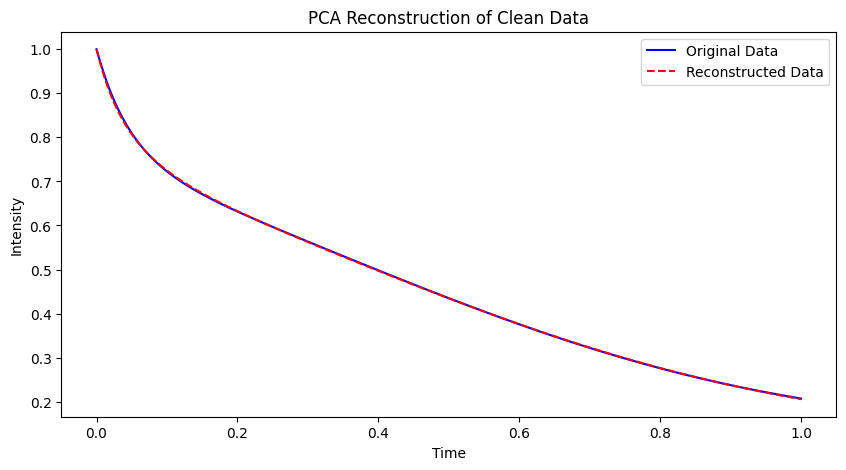

In [10]:
n = np.random.randint(0, len(data_i_clean_train))  # Randomly select an index for plotting
# plot samples from data_i_clean_train and data_i_train_reconstructed_clean
plt.figure(figsize=(10, 5))
plt.plot(t, data_i_clean_train[n], label='Original Data', color='blue')
plt.plot(t, data_i_train_reconstructed_clean[n], label='Reconstructed Data', color='red', linestyle='--')
plt.title('PCA Reconstruction of Clean Data')
plt.xlabel('Time')
plt.ylabel('Intensity')
plt.legend()
plt.show()

In [11]:
# Train PCA model on noisy data
pca_i = PCA(n_components=4, svd_solver='full')
pca_i.fit(data_i_noisy_train)

# Number of principal components
n_components_i = pca_i.n_components_
print(f"Number of principal components: {n_components_i}")

# Transform and inverse transform data_i_train
data_i_train_pca_noisy = pca_i.transform(data_i_noisy_train)
data_i_train_reconstructed_noisy = pca_i.inverse_transform(data_i_train_pca_noisy)

# Calculate mean squared error for data_i_train
mse_train = np.mean((data_i_noisy_train - data_i_train_reconstructed_noisy)**2)
print(f"Mean Squared Error for data_i_train: {mse_train}")

# Transform and inverse transform data_i_test
data_i_test_pca_noisy = pca_i.transform(data_i_noisy_test)
data_i_test_reconstructed_noisy = pca_i.inverse_transform(data_i_test_pca_noisy)

# Calculate mean squared error for data_i_test
mse_test = np.mean((data_i_noisy_test - data_i_test_reconstructed_noisy)**2)
print(f"Mean Squared Error for data_i_test: {mse_test}")

Number of principal components: 4
Mean Squared Error for data_i_train: 0.00017011024284425527
Mean Squared Error for data_i_test: 0.00017082980742666627


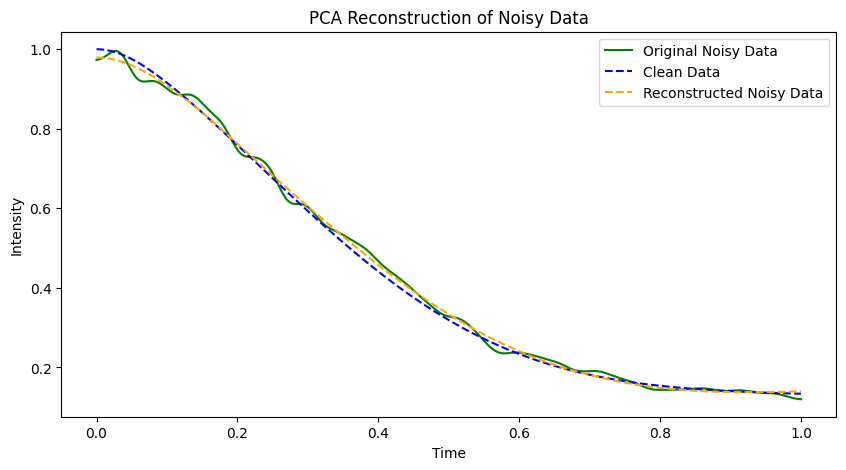

In [12]:
n = np.random.randint(0, len(data_i_noisy_test))

# plot sample from data_i_noisy_train and data_i_train_reconstructed_noisy
plt.figure(figsize=(10, 5))
plt.plot(t, data_i_noisy_test[n], label='Original Noisy Data', color='green')
plt.plot(t, data_i_clean_test[n], label='Clean Data', color='blue', linestyle='--')
plt.plot(t, data_i_test_reconstructed_noisy[n], label='Reconstructed Noisy Data', color='orange', linestyle='--')
plt.title('PCA Reconstruction of Noisy Data')
plt.xlabel('Time')
plt.ylabel('Intensity')
plt.legend()
plt.show()

In [13]:
enhahnced_data_i_train_clean = np.hstack((data_i_train_pca_clean, data_f0_train, data_ts_train, data_h0_train))
enhahnced_data_i_test_clean = np.hstack((data_i_test_pca_clean, data_f0_test, data_ts_test, data_h0_test))
print(enhahnced_data_i_train_clean.shape)

enhahnced_data_i_train_noisy = np.hstack((data_i_train_pca_noisy, data_f0_train, data_ts_train, data_h0_train))
enhahnced_data_i_test_noisy = np.hstack((data_i_test_pca_noisy, data_f0_test, data_ts_test, data_h0_test))

(18343, 7)


In [14]:
# from sklearn.metrics import mean_squared_error

# Train PCA model
pca_c = PCA(n_components=4, svd_solver='full')
pca_c.fit(data_c_train)

# Number of principal components
n_components_c = pca_c.n_components_
print(f"Number of principal components: {n_components_c}")

# Transform and inverse transform data_i_train
data_c_train_pca = pca_c.transform(data_c_train)
data_c_train_reconstructed = pca_c.inverse_transform(data_c_train_pca)

# Calculate mean squared error for data_i_train
mse_train = np.mean((data_c_train - data_c_train_reconstructed)**2)
print(f"Mean Squared Error for data_c_train: {mse_train}")

# Transform and inverse transform data_i_test
data_c_test_pca = pca_c.transform(data_c_test)
data_c_test_reconstructed = pca_c.inverse_transform(data_c_test_pca)

# Calculate mean squared error for data_i_test
mse_test = np.mean((data_c_test - data_c_test_reconstructed)**2)
print(f"Mean Squared Error for data_c_test: {mse_test}")

Number of principal components: 4
Mean Squared Error for data_c_train: 1.1305630633786065e-06
Mean Squared Error for data_c_test: 1.0438831338682399e-06


In [15]:
# Train PCA model
pca_h = PCA(n_components=4, svd_solver='full')
pca_h.fit(data_h_train)

# Number of principal components
n_components_h = pca_h.n_components_
print(f"Number of principal components: {n_components_h}")

# Transform and inverse transform data_i_train
data_h_train_pca = pca_h.transform(data_h_train)
data_h_train_reconstructed = pca_h.inverse_transform(data_h_train_pca)

# Calculate mean squared error for data_i_train
mse_train = np.mean((data_h_train - data_h_train_reconstructed)**2)
print(f"Mean Squared Error for data_h_train: {mse_train}")

# Transform and inverse transform data_i_test
data_h_test_pca = pca_h.transform(data_h_test)
data_h_test_reconstructed = pca_h.inverse_transform(data_h_test_pca)

# Calculate mean squared error for data_i_test
mse_test = np.mean((data_h_test - data_h_test_reconstructed)**2)
print(f"Mean Squared Error for data_c_test: {mse_test}")

Number of principal components: 4
Mean Squared Error for data_h_train: 1.014160462336319e-06
Mean Squared Error for data_c_test: 9.819604376024488e-07


In [16]:
X_train_clean = enhahnced_data_i_train_clean.astype(np.float32)
X_train_noisy = enhahnced_data_i_train_noisy.astype(np.float32)
y_train_c = data_c_train_pca.astype(np.float32)

In [17]:
X_test_clean = enhahnced_data_i_test_clean.astype(np.float32)
X_test_noisy = enhahnced_data_i_test_noisy.astype(np.float32)
y_test_c = data_c_test_pca.astype(np.float32)

In [18]:
data_c_clean = dde.data.dataset.DataSet(
    X_train=X_train_clean, y_train=y_train_c, X_test=X_test_clean, y_test=y_test_c
)

data_c_noisy = dde.data.dataset.DataSet(
    X_train=X_train_noisy, y_train=y_train_c, X_test=X_test_noisy, y_test=y_test_c
)

In [19]:
net_c_clean = dde.nn.fnn.FNN(
    [n_components_i+3, 300, 400, 500, 400, 300, n_components_c],
    "relu",
    "Glorot normal",
)

net_c_noisy = dde.nn.fnn.FNN(
    [n_components_i+3, 300, 400, 500, 400, 300, n_components_c],
    "relu",
    "Glorot normal",
)

In [20]:
def compute_parameters(layers):
    params = 0
    for i in range(len(layers) - 1):
        params += layers[i] * layers[i + 1]  # Weights
        params += layers[i + 1]             # Biases
    return params

branch_layers = [n_components_i+3, 300, 400, 500, 400, 300, n_components_c]

branch_params = compute_parameters(branch_layers)
total_params = branch_params
print(f"Total trainable parameters: {total_params}")


Total trainable parameters: 645204


In [85]:
model_c_clean = dde.Model(data_c_clean, net_c_clean)
model_c_noisy = dde.Model(data_c_noisy, net_c_noisy)

In [38]:
def custom_loss(pred, true):
    return tf.reduce_mean((pca_c.inverse_transform(pred) - pca_c.inverse_transform(true))**2)

In [86]:
model_c_clean.compile("adam", lr=0.001, loss='mse', metrics=["l2 relative error"])
# path = 'C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/fnn_pca_c/model_c_fnn_pca_enhanced_clean-1000.pt'
# model_c_clean.restore(path)
losshistory_c_clean, train_state_c_clean = model_c_clean.train(iterations=1000, display_every=100)

model_c_noisy.compile("adam", lr=0.001, loss='mse', metrics=["l2 relative error"])
# path = 'C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/fnn_pca_c/model_c_fnn_pca_enhanced_noisy-1000.pt'
# model_c_noisy.restore(path)
losshistory_c_noisy, train_state_c_noisy = model_c_noisy.train(iterations=1000, display_every=100)

Compiling model...
'compile' took 0.338241 s

Training model...

0         [3.49e+02]    [3.50e+02]    [3.02e+00]    
100       [1.40e+01]    [1.37e+01]    [5.98e-01]    
200       [8.77e+00]    [8.75e+00]    [4.78e-01]    
300       [4.81e+00]    [4.59e+00]    [3.46e-01]    
400       [2.54e+00]    [2.40e+00]    [2.50e-01]    
500       [2.37e+00]    [2.27e+00]    [2.43e-01]    
600       [2.00e+00]    [1.81e+00]    [2.17e-01]    
700       [2.30e+00]    [2.22e+00]    [2.40e-01]    
800       [1.69e+00]    [1.58e+00]    [2.03e-01]    
900       [1.59e+00]    [1.44e+00]    [1.93e-01]    
1000      [1.27e+00]    [1.14e+00]    [1.73e-01]    

Best model at step 1000:
  train loss: 1.27e+00
  test loss: 1.14e+00
  test metric: [1.73e-01]

'train' took 163.886589 s

Compiling model...
'compile' took 0.324604 s

Training model...

Step      Train loss    Test loss     Test metric   
0         [3.49e+02]    [3.50e+02]    [3.02e+00]    
100       [1.40e+01]    [1.38e+01]    [5.99e-01]    
200

In [22]:
# model_c.compile("adam", lr=0.0001, loss="mse", metrics=["l2 relative error"])
# losshistory_c, train_state_c = model_c.train(iterations=500, display_every=100)

In [40]:
y_train_h = data_h_train_pca.astype(np.float32)
y_test_h = data_h_test_pca.astype(np.float32)

In [41]:
data_h_clean = dde.data.dataset.DataSet(
    X_train=X_train_clean, y_train=y_train_h, X_test=X_test_clean, y_test=y_test_h
)

data_h_noisy = dde.data.dataset.DataSet(
    X_train=X_train_noisy, y_train=y_train_h, X_test=X_test_noisy, y_test=y_test_h
)

In [42]:
m = 601
dim_x = 1
net_h_clean = dde.nn.fnn.FNN(
    [n_components_i+3, 300, 400, 500, 400, 300, n_components_h],
    "relu",
    "Glorot normal",
)

net_h_noisy = dde.nn.fnn.FNN(
    [n_components_i+3, 300, 400, 500, 400, 300, n_components_h],
    "relu",
    "Glorot normal",
)

In [87]:
model_h_clean = dde.Model(data_h_clean, net_h_clean)
model_h_noisy = dde.Model(data_h_noisy, net_h_noisy)

In [88]:
model_h_clean.compile("adam", lr=0.001, loss='mse', metrics=["l2 relative error"])
# path = 'C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/fnn_pca_h/model_h_fnn_pca_enhanced_clean-1000.pt'
# model_h_clean.restore(path)
losshistory_h_clean, train_state_h_clean = model_h_clean.train(iterations=1000, display_every=100)

model_h_noisy.compile("adam", lr=0.001, loss='mse', metrics=["l2 relative error"])
# path = 'C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/fnn_pca_h/model_h_fnn_pca_enhanced_noisy-1000.pt'
# model_h_noisy.restore(path)
losshistory_h_noisy, train_state_h_noisy = model_h_noisy.train(iterations=1000, display_every=100)

Compiling model...
'compile' took 0.399603 s

Training model...

Step      Train loss    Test loss     Test metric   
0         [3.14e+02]    [3.15e+02]    [1.08e+01]    
100       [1.83e+00]    [1.83e+00]    [8.25e-01]    
200       [3.11e-01]    [3.05e-01]    [3.37e-01]    
300       [2.22e-01]    [2.17e-01]    [2.84e-01]    
400       [2.07e-01]    [2.01e-01]    [2.73e-01]    
500       [1.68e-01]    [1.64e-01]    [2.46e-01]    
600       [1.54e-01]    [1.49e-01]    [2.36e-01]    
700       [1.27e-01]    [1.23e-01]    [2.14e-01]    
800       [1.45e-01]    [1.40e-01]    [2.28e-01]    
900       [1.64e-01]    [1.59e-01]    [2.43e-01]    
1000      [1.03e-01]    [9.89e-02]    [1.92e-01]    

Best model at step 1000:
  train loss: 1.03e-01
  test loss: 9.89e-02
  test metric: [1.92e-01]

'train' took 164.569995 s

Compiling model...
'compile' took 0.399822 s

Training model...

Step      Train loss    Test loss     Test metric   
0         [3.14e+02]    [3.15e+02]    [1.08e+01]    
100

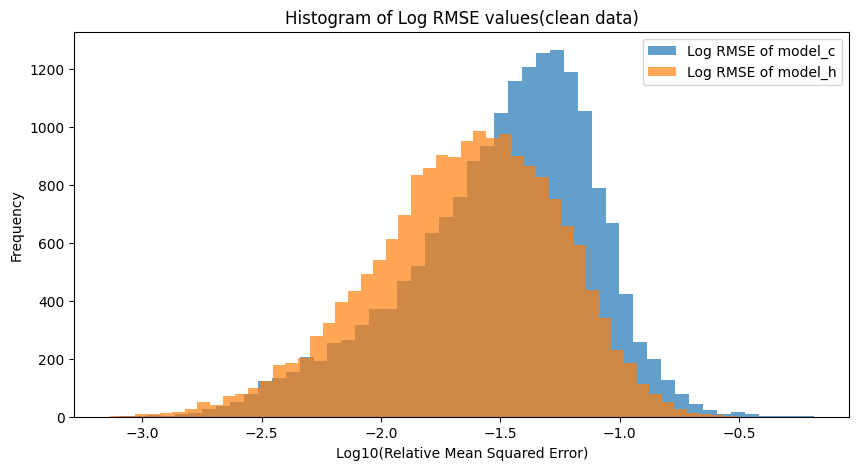

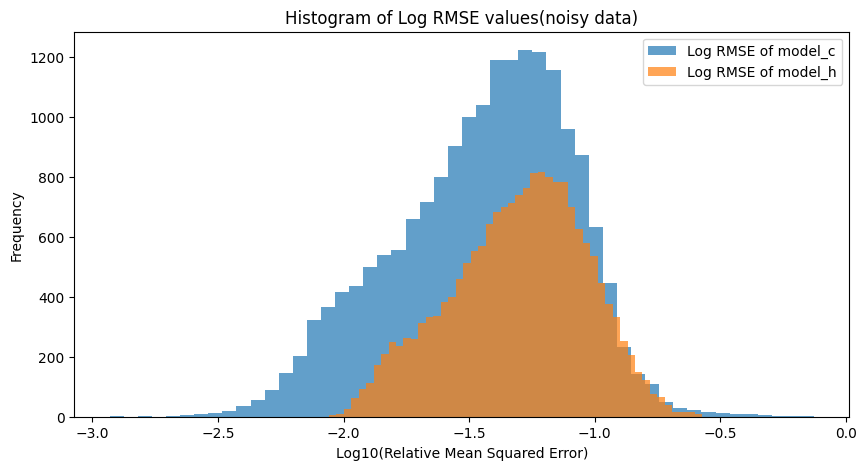

In [89]:
# Use trained model to make predictions
predictions_c_clean = pca_c.inverse_transform(model_c_clean.predict(enhahnced_data_i_test_clean))  # Ensure model_c is defined
predictions_h_clean = pca_h.inverse_transform(model_h_clean.predict(enhahnced_data_i_test_clean))  # Ensure model_h is defined
predictions_c_noisy = pca_c.inverse_transform(model_c_noisy.predict(enhahnced_data_i_test_noisy))  # Ensure model_c is defined
predictions_h_noisy = pca_h.inverse_transform(model_h_noisy.predict(enhahnced_data_i_test_noisy))  # Ensure model_h is defined

# Compute Relative Mean Squared Error (RMSE) for model_c
rrmse_c_clean = np.sqrt(np.sum((predictions_c_clean - data_c_test) ** 2, axis=1) / np.sum((data_c_test ** 2), axis=1))  # Averaging across time points
rrmse_h_clean = np.sqrt(np.sum((predictions_h_clean - data_h_test) ** 2, axis=1) / np.sum((data_h_test ** 2), axis=1))  # Averaging across time points

rrmse_c_noisy = np.sqrt(np.sum((predictions_c_noisy - data_c_test) ** 2, axis=1) / np.sum((data_c_test ** 2), axis=1))  # Averaging across time points
rrmse_h_noisy = np.sqrt(np.sum((predictions_h_noisy - data_h_test) ** 2, axis=1) / np.sum((data_h_test ** 2), axis=1))  # Averaging across time points

# Log-scale histogram
plt.figure(figsize=(10, 5))
plt.hist(np.log10(rrmse_c_clean), bins=50, alpha=0.7, label='Log RMSE of model_c')
plt.hist(np.log10(rrmse_h_clean), bins=50, alpha=0.7, label='Log RMSE of model_h')
plt.xlabel('Log10(Relative Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values(clean data)')
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(np.log10(rrmse_c_noisy), bins=50, alpha=0.7, label='Log RMSE of model_c')
plt.hist(np.log10(rrmse_h_noisy), bins=50, alpha=0.7, label='Log RMSE of model_h')
plt.xlabel('Log10(Relative Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values(noisy data)')
plt.legend()
plt.show()

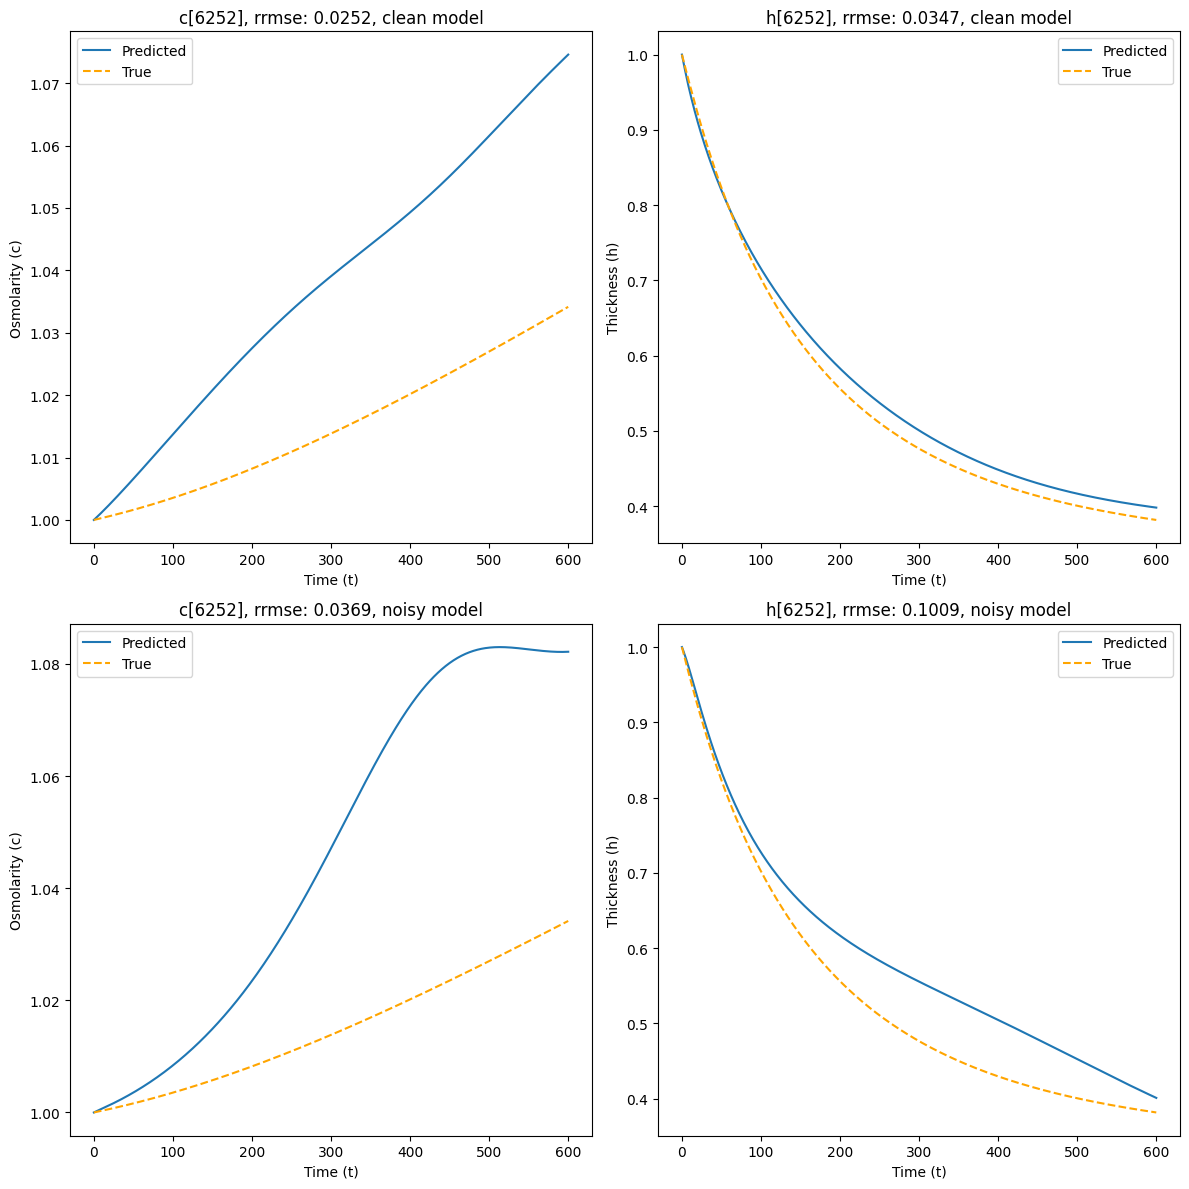

True PCA c: [-8.10076545  0.09151238 -0.13733892  0.01255707]
Predicted PCA c (clean): [[-7.489331   -0.01862771 -0.04755993 -0.01282398]]
Predicted PCA c (noisy): [[-7.1990643  -0.07048883 -0.20534678  0.04074163]]
True PCA h: [-2.69134821 -0.42003026  0.25868437  0.04501521]
Predicted PCA h (clean): [[-2.2550628  -0.31349686  0.11727852 -0.0270436 ]]
Predicted PCA h (noisy): [[-1.3905866  -0.18703148 -0.09861034  0.26165712]]


In [90]:
n = np.random.choice(len(data_i_test_pca_clean))  # Randomly select an index for testing
true_pca_c = data_c_test_pca[n]
pred_pca_c_clean = model_c_clean.predict(enhahnced_data_i_test_clean[n].reshape(1, -1))
pred_c_clean = pca_c.inverse_transform(pred_pca_c_clean)

pred_pca_c_noisy = model_c_noisy.predict(enhahnced_data_i_test_noisy[n].reshape(1, -1))
pred_c_noisy = pca_c.inverse_transform(pred_pca_c_noisy)

true_pca_h = data_h_test_pca[n]
pred_pca_h_clean = model_h_clean.predict(enhahnced_data_i_test_clean[n].reshape(1, -1))
pred_h_clean = pca_h.inverse_transform(pred_pca_h_clean)

pred_pca_h_noisy = model_h_noisy.predict(enhahnced_data_i_test_noisy[n].reshape(1, -1))
pred_h_noisy = pca_h.inverse_transform(pred_pca_h_noisy)

fig, axs = plt.subplots(2, 2, figsize=(12, 12))  # 3 row, 2 columns

# Plot data_c[n]
axs[0,0].plot(pred_c_clean.T)
axs[0,0].plot(data_c_test[n], linestyle='--', color='orange')  # True data for comparison
axs[0,0].set_title(f'c[{n}], rrmse: {rrmse_c_clean[n]:.4f}, clean model')
axs[0,0].set_xlabel('Time (t)')
axs[0,0].set_ylabel('Osmolarity (c)')
axs[0,0].legend(['Predicted', 'True'])

# Plot data_h[n]
axs[0,1].plot(pred_h_clean.T)
axs[0,1].plot(data_h_test[n], linestyle='--', color='orange')  # True data for comparison
axs[0,1].set_title(f'h[{n}], rrmse: {rrmse_h_clean[n]:.4f}, clean model')
axs[0,1].set_xlabel('Time (t)')
axs[0,1].set_ylabel('Thickness (h)')
axs[0,1].legend(['Predicted', 'True'])


# Plot data_c[n]

axs[1,0].plot(pred_c_noisy.T)
axs[1,0].plot(data_c_test[n], linestyle='--', color='orange')  # True data for comparison
axs[1,0].set_title(f'c[{n}], rrmse: {rrmse_c_noisy[n]:.4f}, noisy model')
axs[1,0].set_xlabel('Time (t)')
axs[1,0].set_ylabel('Osmolarity (c)')
axs[1,0].legend(['Predicted', 'True'])

# Plot data_h[n]
axs[1,1].plot(pred_h_noisy.T)
axs[1,1].plot(data_h_test[n], linestyle='--', color='orange')  # True data for comparison
axs[1,1].set_title(f'h[{n}], rrmse: {rrmse_h_noisy[n]:.4f}, noisy model')
axs[1,1].set_xlabel('Time (t)')
axs[1,1].set_ylabel('Thickness (h)')
axs[1,1].legend(['Predicted', 'True'])

plt.tight_layout()
plt.show()

print(f"True PCA c: {true_pca_c}")
print(f"Predicted PCA c (clean): {pred_pca_c_clean}")
print(f"Predicted PCA c (noisy): {pred_pca_c_noisy}")
print(f"True PCA h: {true_pca_h}")
print(f"Predicted PCA h (clean): {pred_pca_h_clean}")
print(f"Predicted PCA h (noisy): {pred_pca_h_noisy}")

In [ ]:
# path = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/fnn_pca_c/model_c_fnn_pca_enhanced_clean"
# model_c_clean.save(path)

INFO:tensorflow:C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/fnn_pca_c/model_c_fnn_pca_enhanced_clean-1000.ckpt is not in all_model_checkpoint_paths. Manually adding it.


'C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/fnn_pca_c/model_c_fnn_pca_enhanced_clean-1000.ckpt'

In [ ]:
# path = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/fnn_pca_c/model_c_fnn_pca_enhanced_noisy"
# model_c_noisy.save(path)

INFO:tensorflow:C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/fnn_pca_c/model_c_fnn_pca_enhanced_noisy-1000.ckpt is not in all_model_checkpoint_paths. Manually adding it.


'C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/fnn_pca_c/model_c_fnn_pca_enhanced_noisy-1000.ckpt'

In [ ]:
# path = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/fnn_pca_h/model_h_fnn_pca_enhanced_clean"
# model_h_clean.save(path)

INFO:tensorflow:C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/fnn_pca_h/model_h_fnn_pca_enhanced_clean-1000.ckpt is not in all_model_checkpoint_paths. Manually adding it.


'C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/fnn_pca_h/model_h_fnn_pca_enhanced_clean-1000.ckpt'

In [ ]:
# path = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/fnn_pca_h/model_h_fnn_pca_enhanced_noisy"
# model_h_noisy.save(path)

INFO:tensorflow:C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/fnn_pca_h/model_h_fnn_pca_enhanced_noisy-1000.ckpt is not in all_model_checkpoint_paths. Manually adding it.


'C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/models/fnn_pca_h/model_h_fnn_pca_enhanced_noisy-1000.ckpt'

In [122]:
datastore_glob = h5py.File("C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/PDE_1d_glob_new_center_filtered.jld2", 'r')
data_I_glob = np.array(np.array(datastore_glob["filtered_data_I"]))

data_c_glob = np.array(np.array(datastore_glob["filtered_data_c"]))
data_h_glob = np.array(np.array(datastore_glob["filtered_data_h"]))

data_p_glob = np.array(np.array(datastore_glob["filtered_para"]))
data_ts_glob = data_p_glob[:,0].reshape(-1, 1)
data_h0_glob = data_p_glob[:,1].reshape(-1, 1)
data_f0_glob = data_p_glob[:,2].reshape(-1, 1)


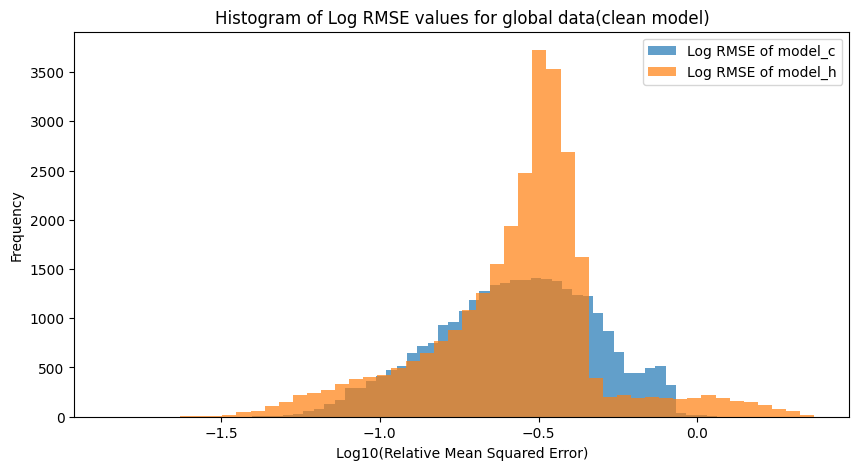

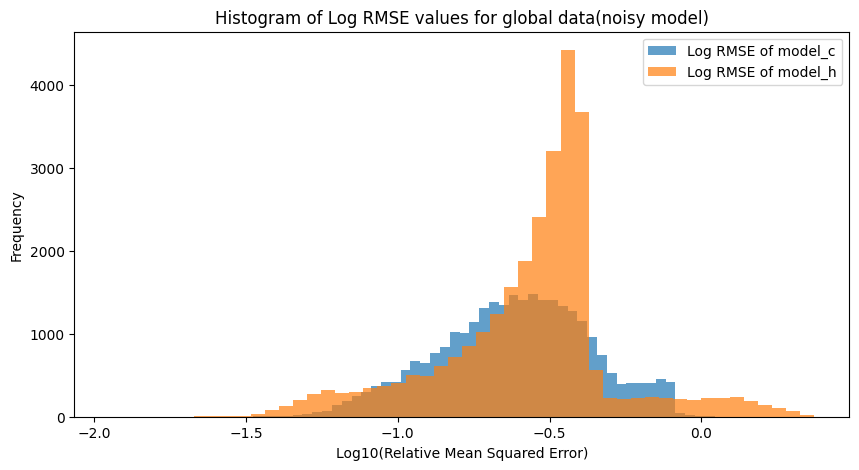

In [123]:
# Prepare the test data
X_test_glob = data_I_glob.astype(np.float32)
X_test_glob_pca_clean = pca_i_clean.transform(X_test_glob)
X_test_glob_pca_clean = np.hstack((X_test_glob_pca_clean, data_f0_glob, data_ts_glob, data_h0_glob)).astype(np.float32)
X_test_glob_pca_noisy = pca_i.transform(X_test_glob)
X_test_glob_pca_noisy = np.hstack((X_test_glob_pca_noisy, data_f0_glob, data_ts_glob, data_h0_glob)).astype(np.float32)

y_test_c_glob = data_c_glob.astype(np.float32)
y_test_c_glob_pca = pca_c.transform(y_test_c_glob)
y_test_h_glob = data_h_glob.astype(np.float32)
y_test_h_glob_pca = pca_h.transform(y_test_h_glob)

# Use trained models to make predictions
predictions_c_glob_clean = pca_c.inverse_transform(model_c_clean.predict(X_test_glob_pca_clean))
predictions_h_glob_clean = pca_h.inverse_transform(model_h_clean.predict(X_test_glob_pca_clean))

predictions_c_glob_noisy = pca_c.inverse_transform(model_c_noisy.predict(X_test_glob_pca_noisy))
predictions_h_glob_noisy = pca_h.inverse_transform(model_h_noisy.predict(X_test_glob_pca_noisy))

# Compute Relative Mean Squared Error (RMSE) for model_c
rrmse_c_glob_clean = np.sqrt(np.sum((predictions_c_glob_clean - y_test_c_glob) ** 2, axis=1) / np.sum(y_test_c_glob ** 2, axis=1))
rrmse_h_glob_clean = np.sqrt(np.sum((predictions_h_glob_clean - y_test_h_glob) ** 2, axis=1) / np.sum(y_test_h_glob ** 2, axis=1))

rrmse_c_glob_noisy = np.sqrt(np.sum((predictions_c_glob_noisy - y_test_c_glob) ** 2, axis=1) / np.sum(y_test_c_glob ** 2, axis=1))
rrmse_h_glob_noisy = np.sqrt(np.sum((predictions_h_glob_noisy - y_test_h_glob) ** 2, axis=1) / np.sum(y_test_h_glob ** 2, axis=1))

# Log-scale histogram
plt.figure(figsize=(10, 5))
plt.hist(np.log10(rrmse_c_glob_clean), bins=50, alpha=0.7, label='Log RMSE of model_c')
plt.hist(np.log10(rrmse_h_glob_clean), bins=50, alpha=0.7, label='Log RMSE of model_h')
plt.xlabel('Log10(Relative Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values for global data(clean model)')
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(np.log10(rrmse_c_glob_noisy), bins=50, alpha=0.7, label='Log RMSE of model_c')
plt.hist(np.log10(rrmse_h_glob_noisy), bins=50, alpha=0.7, label='Log RMSE of model_h')
plt.xlabel('Log10(Relative Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values for global data(noisy model)')
plt.legend()
plt.show()

16441


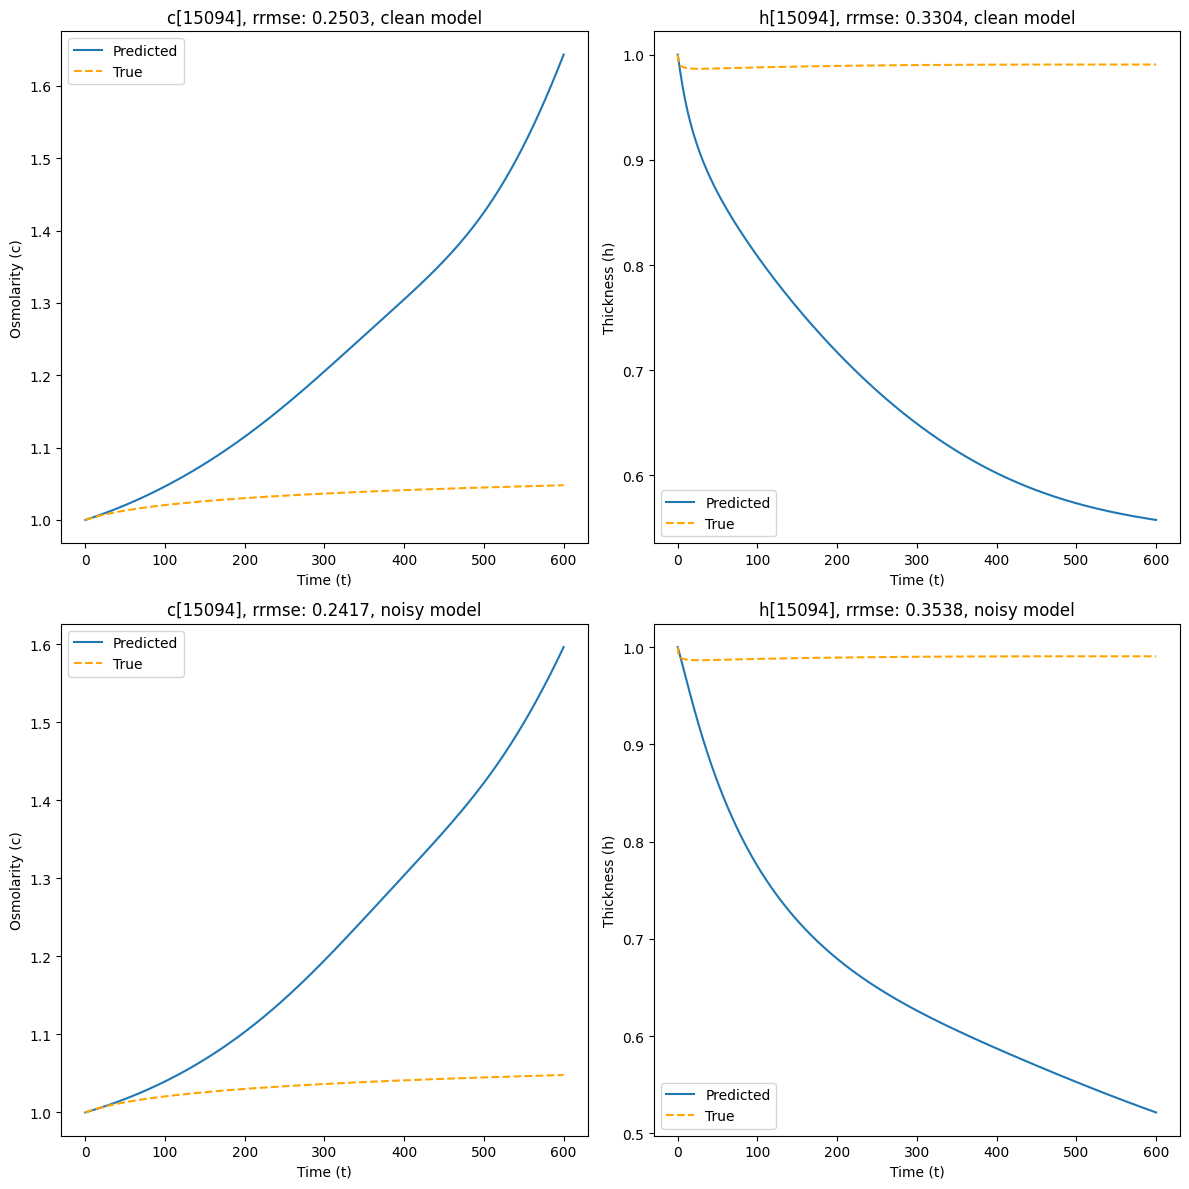

True PCA c: [-7.72320733e+00 -1.22368260e-01  7.56958050e-03 -5.67812094e-02]
Predicted PCA c (clean): [[-1.4193751   0.49938563  0.18945138  0.18860927]]
Predicted PCA c (noisy): [[-1.6291788   0.44260484 -0.0181832   0.15823865]]
True PCA h: [ 9.04822971 -0.11492656 -0.13828512 -0.10830603]
Predicted PCA h (clean): [[ 1.0332139  -0.02501559 -0.05400323 -0.11265902]]
Predicted PCA h (noisy): [[ 0.47050226 -0.24639139 -0.02271912  0.11380475]]


In [124]:
n = np.random.randint(0, len(X_test_glob))
print(n)
n = np.random.choice(len(data_i_test_pca_clean))  # Randomly select an index for testing
true_pca_c = y_test_c_glob_pca[n]
pred_pca_c_clean = model_c_clean.predict(X_test_glob_pca_clean[n].reshape(1, -1))
pred_c_clean = pca_c.inverse_transform(pred_pca_c_clean)

pred_pca_c_noisy = model_c_noisy.predict(X_test_glob_pca_noisy[n].reshape(1, -1))
pred_c_noisy = pca_c.inverse_transform(pred_pca_c_noisy)

true_pca_h = y_test_h_glob_pca[n]
pred_pca_h_clean = model_h_clean.predict(X_test_glob_pca_clean[n].reshape(1, -1))
pred_h_clean = pca_h.inverse_transform(pred_pca_h_clean)

pred_pca_h_noisy = model_h_noisy.predict(X_test_glob_pca_noisy[n].reshape(1, -1))
pred_h_noisy = pca_h.inverse_transform(pred_pca_h_noisy)

fig, axs = plt.subplots(2, 2, figsize=(12, 12))  # 3 row, 2 columns

# Plot data_c[n]
axs[0,0].plot(pred_c_clean.T)
axs[0,0].plot(y_test_c_glob[n], linestyle='--', color='orange')  # True data for comparison
axs[0,0].set_title(f'c[{n}], rrmse: {rrmse_c_glob_clean[n]:.4f}, clean model')
axs[0,0].set_xlabel('Time (t)')
axs[0,0].set_ylabel('Osmolarity (c)')
axs[0,0].legend(['Predicted', 'True'])

# Plot data_h[n]
axs[0,1].plot(pred_h_clean.T)
axs[0,1].plot(y_test_h_glob[n], linestyle='--', color='orange')  # True data for comparison
axs[0,1].set_title(f'h[{n}], rrmse: {rrmse_h_glob_clean[n]:.4f}, clean model')
axs[0,1].set_xlabel('Time (t)')
axs[0,1].set_ylabel('Thickness (h)')
axs[0,1].legend(['Predicted', 'True'])


# Plot data_c[n]

axs[1,0].plot(pred_c_noisy.T)
axs[1,0].plot(y_test_c_glob[n], linestyle='--', color='orange')  # True data for comparison
axs[1,0].set_title(f'c[{n}], rrmse: {rrmse_c_glob_noisy[n]:.4f}, noisy model')
axs[1,0].set_xlabel('Time (t)')
axs[1,0].set_ylabel('Osmolarity (c)')
axs[1,0].legend(['Predicted', 'True'])

# Plot data_h[n]
axs[1,1].plot(pred_h_noisy.T)
axs[1,1].plot(y_test_h_glob[n], linestyle='--', color='orange')  # True data for comparison
axs[1,1].set_title(f'h[{n}], rrmse: {rrmse_h_glob_noisy[n]:.4f}, noisy model')
axs[1,1].set_xlabel('Time (t)')
axs[1,1].set_ylabel('Thickness (h)')
axs[1,1].legend(['Predicted', 'True'])

plt.tight_layout()
plt.show()

print(f"True PCA c: {true_pca_c}")
print(f"Predicted PCA c (clean): {pred_pca_c_clean}")
print(f"Predicted PCA c (noisy): {pred_pca_c_noisy}")
print(f"True PCA h: {true_pca_h}")
print(f"Predicted PCA h (clean): {pred_pca_h_clean}")
print(f"Predicted PCA h (noisy): {pred_pca_h_noisy}")

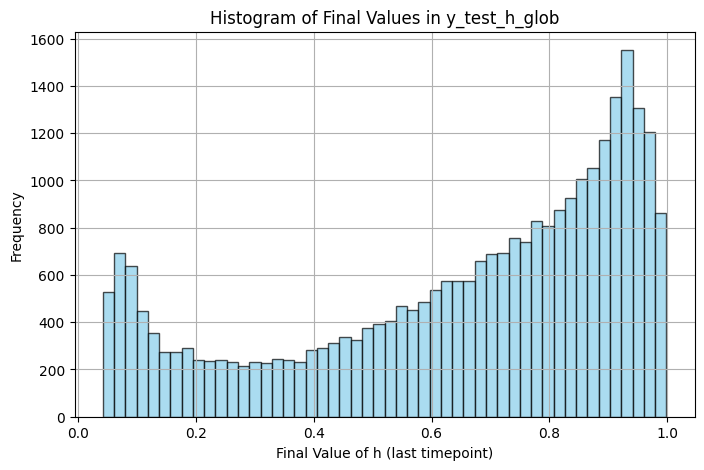

In [125]:
plt.figure(figsize=(8, 5))
plt.hist(y_test_h_glob[:, -1], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
plt.xlabel('Final Value of h (last timepoint)')
plt.ylabel('Frequency')
plt.title('Histogram of Final Values in y_test_h_glob')
plt.grid(True)
plt.show()

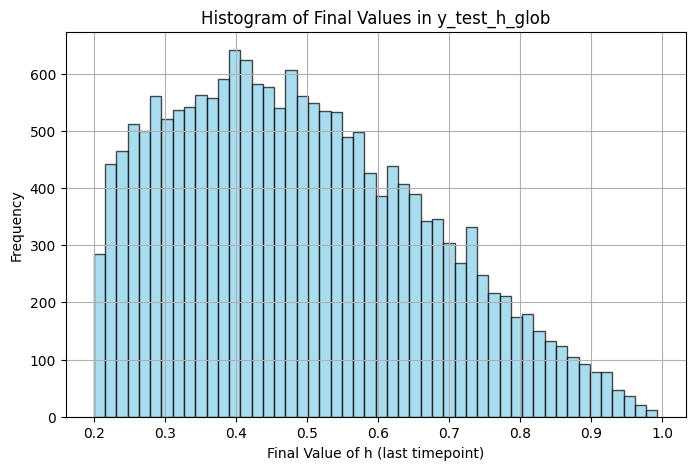

In [126]:
plt.figure(figsize=(8, 5))
plt.hist(data_h_test[:, -1], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
plt.xlabel('Final Value of h (last timepoint)')
plt.ylabel('Frequency')
plt.title('Histogram of Final Values in y_test_h_glob')
plt.grid(True)
plt.show()

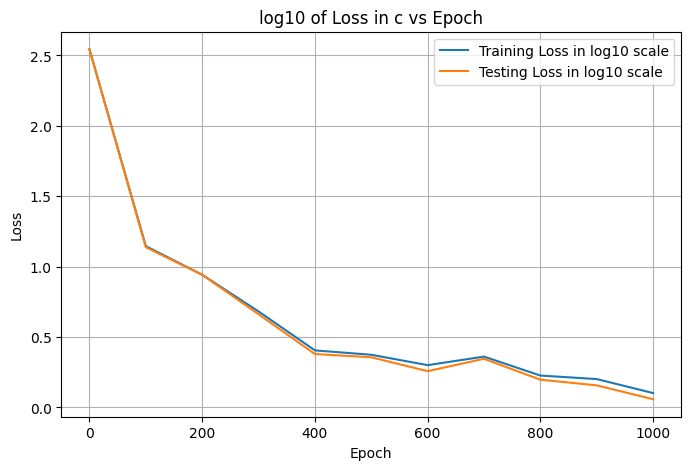

In [127]:
plt.figure(figsize=(8, 5))
plt.plot(losshistory_c_clean.steps, np.log10(losshistory_c_clean.loss_train), label='Training Loss in log10 scale')
plt.plot(losshistory_c_clean.steps, np.log10(losshistory_c_clean.loss_test), label='Testing Loss in log10 scale')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('log10 of Loss in c vs Epoch')
plt.legend()
plt.grid(True)
plt.show()

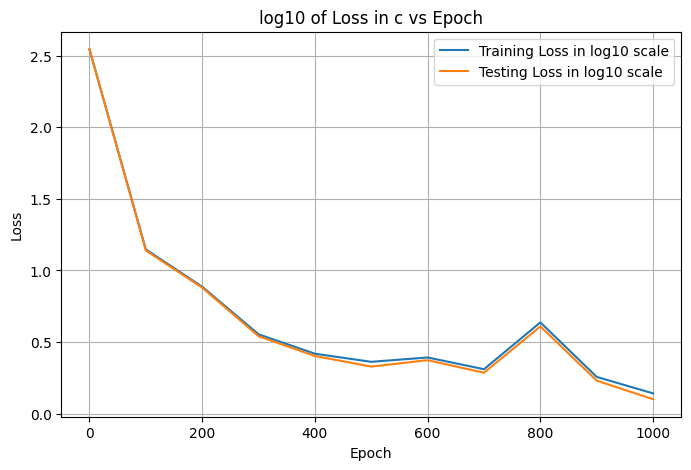

In [128]:
plt.figure(figsize=(8, 5))
plt.plot(losshistory_c_noisy.steps, np.log10(losshistory_c_noisy.loss_train), label='Training Loss in log10 scale')
plt.plot(losshistory_c_noisy.steps, np.log10(losshistory_c_noisy.loss_test), label='Testing Loss in log10 scale')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('log10 of Loss in c vs Epoch')
plt.legend()
plt.grid(True)
plt.show()

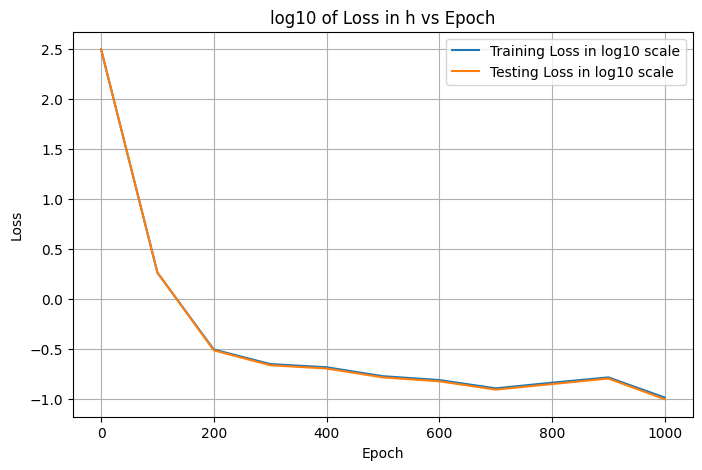

In [129]:
plt.figure(figsize=(8, 5))
plt.plot(losshistory_h_clean.steps, np.log10(losshistory_h_clean.loss_train), label='Training Loss in log10 scale')
plt.plot(losshistory_h_clean.steps, np.log10(losshistory_h_clean.loss_test), label='Testing Loss in log10 scale')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('log10 of Loss in h vs Epoch')
plt.legend()
plt.grid(True)
plt.show()

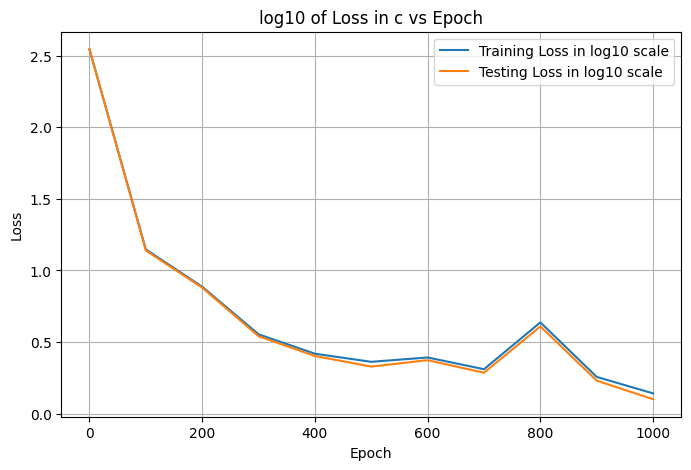

In [130]:
plt.figure(figsize=(8, 5))
plt.plot(losshistory_c_noisy.steps, np.log10(losshistory_c_noisy.loss_train), label='Training Loss in log10 scale')
plt.plot(losshistory_c_noisy.steps, np.log10(losshistory_c_noisy.loss_test), label='Testing Loss in log10 scale')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('log10 of Loss in c vs Epoch')
plt.legend()
plt.grid(True)
plt.show()

<!-- # Testing the model on experimental data -->

In [131]:
exprimental_data_path = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/experimental_data_dimensional.txt"
exprimental_data_path_h5 = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/experimental_data_dimensional_2.h5"
exprimental_data_nondimensional_path_h5 = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/datasets/experimental_data_nondimensional_2.h5"

In [132]:
with h5py.File(exprimental_data_path_h5, 'r') as h5f:
    t = h5f['t'][:]
    I = h5f['I'][:]
    p = h5f['p'][:]
    
I_scaled = np.array([row / row[0] for row in I], dtype=object)


In [133]:
def scale_time_arrays(t):
    """
    Linearly scale each time array so that:
      - the first value becomes 0
      - the value equal to ts becomes 1

    Parameters:
    - t: list or array of 1D numpy arrays (ragged)
    - ts_array: 1D array of float, ts for each instance

    Returns:
    - t_scaled: list of scaled time arrays with same structure
    """
    t_scaled = []

    for i in range(len(t)):
        t_i = t[i]
        t0 = t_i[0]
        t_end = t_i[-1]  # Assuming ts is the last value in the array

        t_scaled_i = (t_i - t0) / (t_end - t0)
        t_scaled.append(t_scaled_i)

    return np.array(t_scaled, dtype=object)


In [134]:
with h5py.File(exprimental_data_path_h5, 'r') as h5f:
    t_group = h5f['t']
    # Structured array access for 'ts'
    ts_array = h5f['p']['ts']
    id_array = h5f['p']['id']

t_scaled = scale_time_arrays(t)


In [135]:
from scipy.interpolate import PchipInterpolator

# Interpolate each row of t_scaled and I_scaled to length 601
n_points = 601
t_uniform = np.linspace(0, 1, n_points)

t_scaled_interp = []
I_scaled_interp = []

for t_row, I_row in zip(t_scaled, I_scaled):
    # Interpolators
    t_interp = t_uniform  # target x-axis
    I_interp_func = PchipInterpolator(t_row, I_row)
    I_interp = I_interp_func(t_interp)
    t_scaled_interp.append(t_interp)
    I_scaled_interp.append(I_interp)

t_scaled_interp = np.array(t_scaled_interp)
I_scaled_interp = np.array(I_scaled_interp)

In [136]:
datastore = h5py.File(exprimental_data_nondimensional_path_h5, 'r')
print(list(datastore.keys()))
data_I_calculated = np.array(datastore["calculated_I"])
data_h_calculated = np.array(datastore["calculated_h"])
data_f_calculated = np.array(datastore["calculated_f"])

data_c_caluculated = np.array(datastore["calculated_c"])
data_p_experimental_nondimensional = np.array(datastore["nondimensional_p"])

J_e_exp = data_p_experimental_nondimensional[:, 0]
b_1_exp = data_p_experimental_nondimensional[:, 1]
b_2_exp = data_p_experimental_nondimensional[:, 2]
h_e_exp = data_p_experimental_nondimensional[:, 3]
f0_data_exp = data_p_experimental_nondimensional[:, 4] * 1e3
Pc_exp = data_p_experimental_nondimensional[:, 5]
phi_exp = data_p_experimental_nondimensional[:, 6]
h0_data_exp = data_p_experimental_nondimensional[:, 7] * 1e6
ts_data_exp = data_p_experimental_nondimensional[:, 8]
residual_exp = data_p_experimental_nondimensional[:, 9] 

datastore.close()  # Close the read-only handle

['calculated_I', 'calculated_c', 'calculated_f', 'calculated_h', 'nondimensional_p']


In [137]:
# print(np.max(f0_exp), np.min(f0_exp), np.max(ts_exp), np.min(ts_data_exp), np.max(h0_data_exp), np.min(h0_data_exp))
# print(np.max(f0_data), np.min(f0_data), np.max(ts_data), np.min(ts_data), np.max(h0_data), np.min(h0_data))

Experimental RMSE for model_c_clean: 0.14707920992557424
Experimental RMSE for model_h_clean: 0.07160483121260432
Experimental RMSE for model_c_noisy: 0.13667198679155326
Experimental RMSE for model_h_noisy: 0.09337976184570299


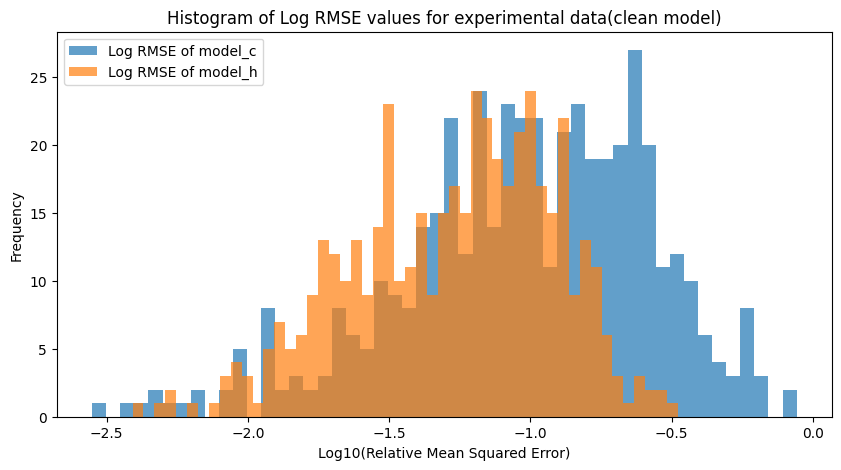

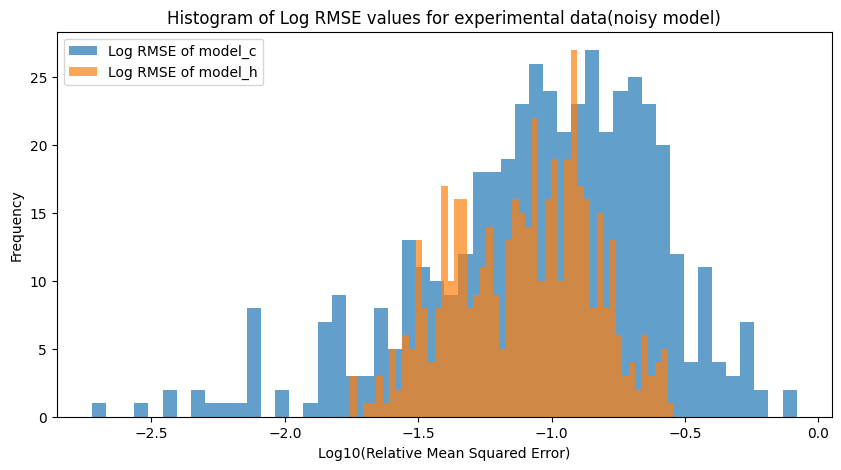

In [138]:
# Prepare the test data
X_test_expr = I_scaled_interp.astype(np.float32)
y_test_c_calculated = data_c_caluculated.astype(np.float32)
y_test_h_calculated = data_h_calculated.astype(np.float32)

X_test_calculated_pca_clean = pca_i_clean.transform(X_test_expr)
X_test_calculated_pca_clean = np.hstack((X_test_calculated_pca_clean, f0_data_exp[:,np.newaxis], ts_data_exp[:,np.newaxis], h0_data_exp[:,np.newaxis])).astype(np.float32)

X_test_calculated_pca_noisy = pca_i.transform(X_test_expr)
X_test_calculated_pca_noisy = np.hstack((X_test_calculated_pca_noisy, f0_data_exp[:,np.newaxis], ts_data_exp[:,np.newaxis], h0_data_exp[:,np.newaxis])).astype(np.float32)
y_test_c_calculated_pca = pca_c.transform(y_test_c_calculated)
y_test_h_calculated_pca = pca_h.transform(y_test_h_calculated)


# Use trained models to make predictions
predictions_c_calculated_pca_claen = model_c_clean.predict(X_test_calculated_pca_clean)
predictions_h_calculated_pca_clean = model_h_clean.predict(X_test_calculated_pca_clean)

predictions_c_calculated_pca_noisy = model_c_noisy.predict(X_test_calculated_pca_noisy)
predictions_h_calculated_pca_noisy = model_h_noisy.predict(X_test_calculated_pca_noisy)

predictions_c_calculated_clean = pca_c.inverse_transform(predictions_c_calculated_pca_claen)
predictions_h_calculated_clean = pca_h.inverse_transform(predictions_h_calculated_pca_clean)

predictions_c_calculated_noisy = pca_c.inverse_transform(predictions_c_calculated_pca_noisy)
predictions_h_calculated_noisy = pca_h.inverse_transform(predictions_h_calculated_pca_noisy)

# Compute Relative Mean Squared Error (RMSE) for model_c
rrmse_c_calculated_clean = np.sqrt(np.mean((predictions_c_calculated_clean - y_test_c_calculated) ** 2, axis=1) / np.mean((y_test_c_calculated ** 2), axis=1))
rrmse_h_calculated_clean = np.sqrt(np.mean((predictions_h_calculated_clean - y_test_h_calculated) ** 2, axis=1) / np.mean((y_test_h_calculated ** 2), axis=1))

rrmse_c_calculated_noisy = np.sqrt(np.mean((predictions_c_calculated_noisy - y_test_c_calculated) ** 2, axis=1) / np.mean((y_test_c_calculated ** 2), axis=1))
rrmse_h_calculated_noisy = np.sqrt(np.mean((predictions_h_calculated_noisy - y_test_h_calculated) ** 2, axis=1) / np.mean((y_test_h_calculated ** 2), axis=1))

print("Experimental RMSE for model_c_clean:", np.mean(rrmse_c_calculated_clean))
print("Experimental RMSE for model_h_clean:", np.mean(rrmse_h_calculated_clean))
print("Experimental RMSE for model_c_noisy:", np.mean(rrmse_c_calculated_noisy))
print("Experimental RMSE for model_h_noisy:", np.mean(rrmse_h_calculated_noisy))


# Log-scale histogram
plt.figure(figsize=(10, 5))
plt.hist(np.log10(rrmse_c_calculated_clean), bins=50, alpha=0.7, label='Log RMSE of model_c')
plt.hist(np.log10(rrmse_h_calculated_clean), bins=50, alpha=0.7, label='Log RMSE of model_h')
plt.xlabel('Log10(Relative Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values for experimental data(clean model)')
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(np.log10(rrmse_c_calculated_noisy), bins=50, alpha=0.7, label='Log RMSE of model_c')
plt.hist(np.log10(rrmse_h_calculated_noisy), bins=50, alpha=0.7, label='Log RMSE of model_h')
plt.xlabel('Log10(Relative Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values for experimental data(noisy model)')
plt.legend()
plt.show()

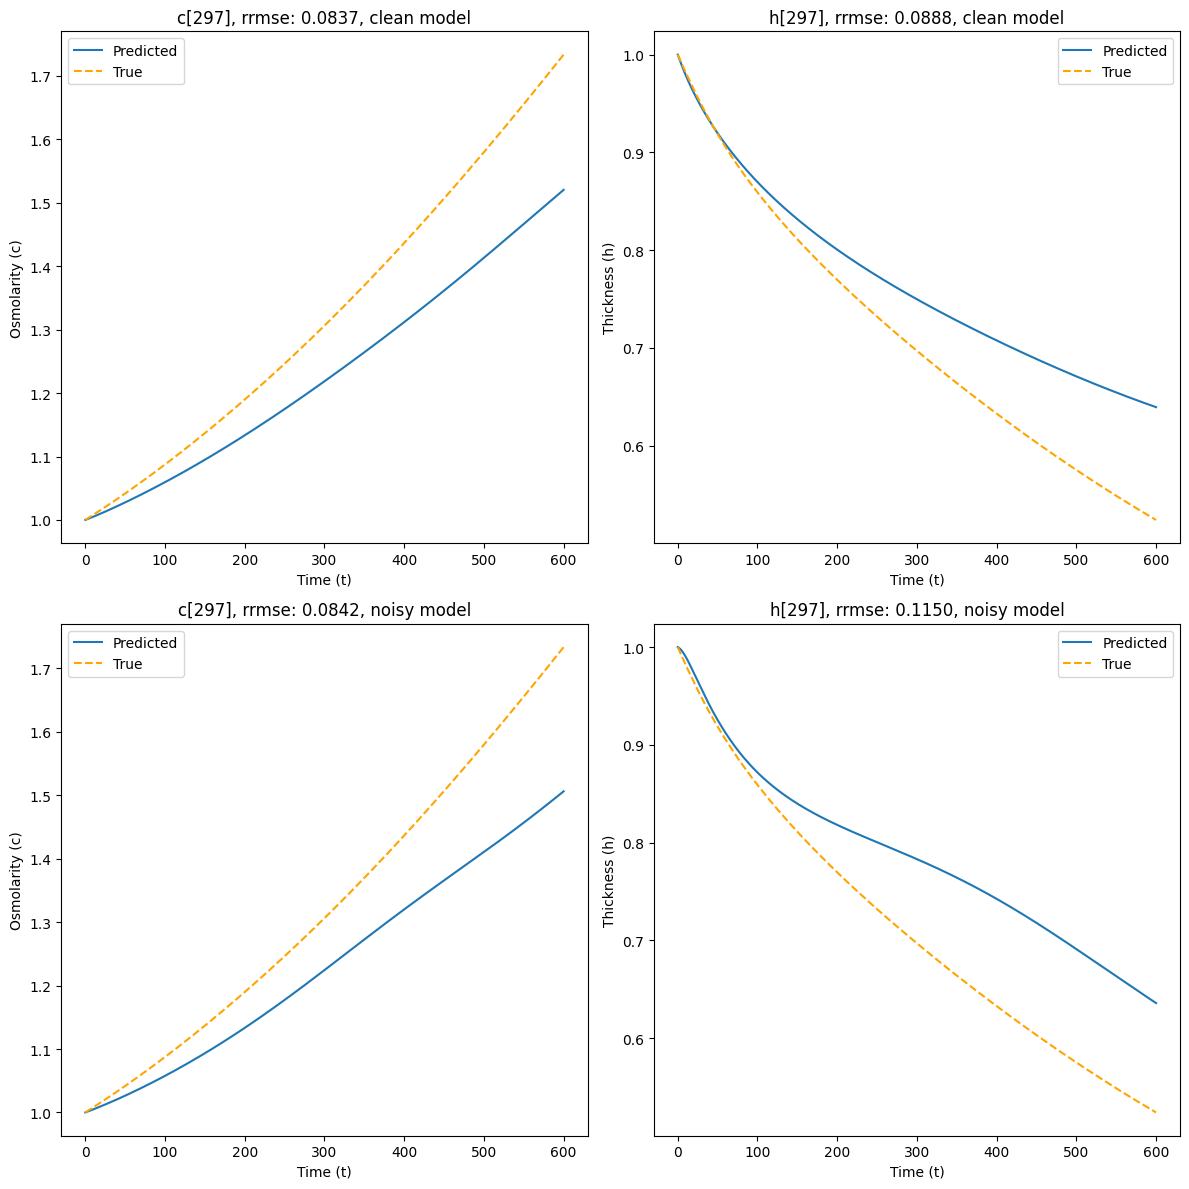

True PCA c: [ 1.019324   -0.18728302  0.28364076 -0.04497459]
Predicted PCA c (clean): [[-1.7340422  -0.10590725  0.13215369 -0.01032316]]
Predicted PCA c (noisy): [[-1.7468133  -0.23238756  0.08491501  0.031851  ]]
True PCA h: [ 8.48855836e-01 -1.23972912e-01  1.82224977e-01  6.43574394e-04]
Predicted PCA h (clean): [[ 3.146331    0.2651191  -0.11553174  0.04415709]]
Predicted PCA h (noisy): [[ 3.6332633   0.31323218 -0.2764401   0.25482896]]


In [139]:
n = np.random.choice(len(X_test_expr))  # Randomly select an index for testing
true_pca_c = y_test_c_calculated_pca[n]
pred_pca_c_clean = model_c_clean.predict(X_test_calculated_pca_clean[n].reshape(1, -1))
pred_c_clean = pca_c.inverse_transform(pred_pca_c_clean)

pred_pca_c_noisy = model_c_noisy.predict(X_test_calculated_pca_noisy[n].reshape(1, -1))
pred_c_noisy = pca_c.inverse_transform(pred_pca_c_noisy)

true_pca_h = data_h_test_pca[n]
pred_pca_h_clean = model_h_clean.predict(X_test_calculated_pca_clean[n].reshape(1, -1))
pred_h_clean = pca_h.inverse_transform(pred_pca_h_clean)

pred_pca_h_noisy = model_h_noisy.predict(X_test_calculated_pca_noisy[n].reshape(1, -1))
pred_h_noisy = pca_h.inverse_transform(pred_pca_h_noisy)

fig, axs = plt.subplots(2, 2, figsize=(12, 12))  # 3 row, 2 columns

# Plot data_c[n]
axs[0,0].plot(pred_c_clean.T)
axs[0,0].plot(y_test_c_calculated[n], linestyle='--', color='orange')  # True data for comparison
axs[0,0].set_title(f'c[{n}], rrmse: {rrmse_c_calculated_clean[n]:.4f}, clean model')
axs[0,0].set_xlabel('Time (t)')
axs[0,0].set_ylabel('Osmolarity (c)')
axs[0,0].legend(['Predicted', 'True'])

# Plot data_h[n]
axs[0,1].plot(pred_h_clean.T)
axs[0,1].plot(y_test_h_calculated[n], linestyle='--', color='orange')  # True data for comparison
axs[0,1].set_title(f'h[{n}], rrmse: {rrmse_h_calculated_clean[n]:.4f}, clean model')
axs[0,1].set_xlabel('Time (t)')
axs[0,1].set_ylabel('Thickness (h)')
axs[0,1].legend(['Predicted', 'True'])


# Plot data_c[n]

axs[1,0].plot(pred_c_noisy.T)
axs[1,0].plot(y_test_c_calculated[n], linestyle='--', color='orange')  # True data for comparison
axs[1,0].set_title(f'c[{n}], rrmse: {rrmse_c_calculated_noisy[n]:.4f}, noisy model')
axs[1,0].set_xlabel('Time (t)')
axs[1,0].set_ylabel('Osmolarity (c)')
axs[1,0].legend(['Predicted', 'True'])

# Plot data_h[n]
axs[1,1].plot(pred_h_noisy.T)
axs[1,1].plot(y_test_h_calculated[n], linestyle='--', color='orange')  # True data for comparison
axs[1,1].set_title(f'h[{n}], rrmse: {rrmse_h_calculated_noisy[n]:.4f}, noisy model')
axs[1,1].set_xlabel('Time (t)')
axs[1,1].set_ylabel('Thickness (h)')
axs[1,1].legend(['Predicted', 'True'])

plt.tight_layout()
plt.show()

print(f"True PCA c: {true_pca_c}")
print(f"Predicted PCA c (clean): {pred_pca_c_clean}")
print(f"Predicted PCA c (noisy): {pred_pca_c_noisy}")
print(f"True PCA h: {true_pca_h}")
print(f"Predicted PCA h (clean): {pred_pca_h_clean}")
print(f"Predicted PCA h (noisy): {pred_pca_h_noisy}")

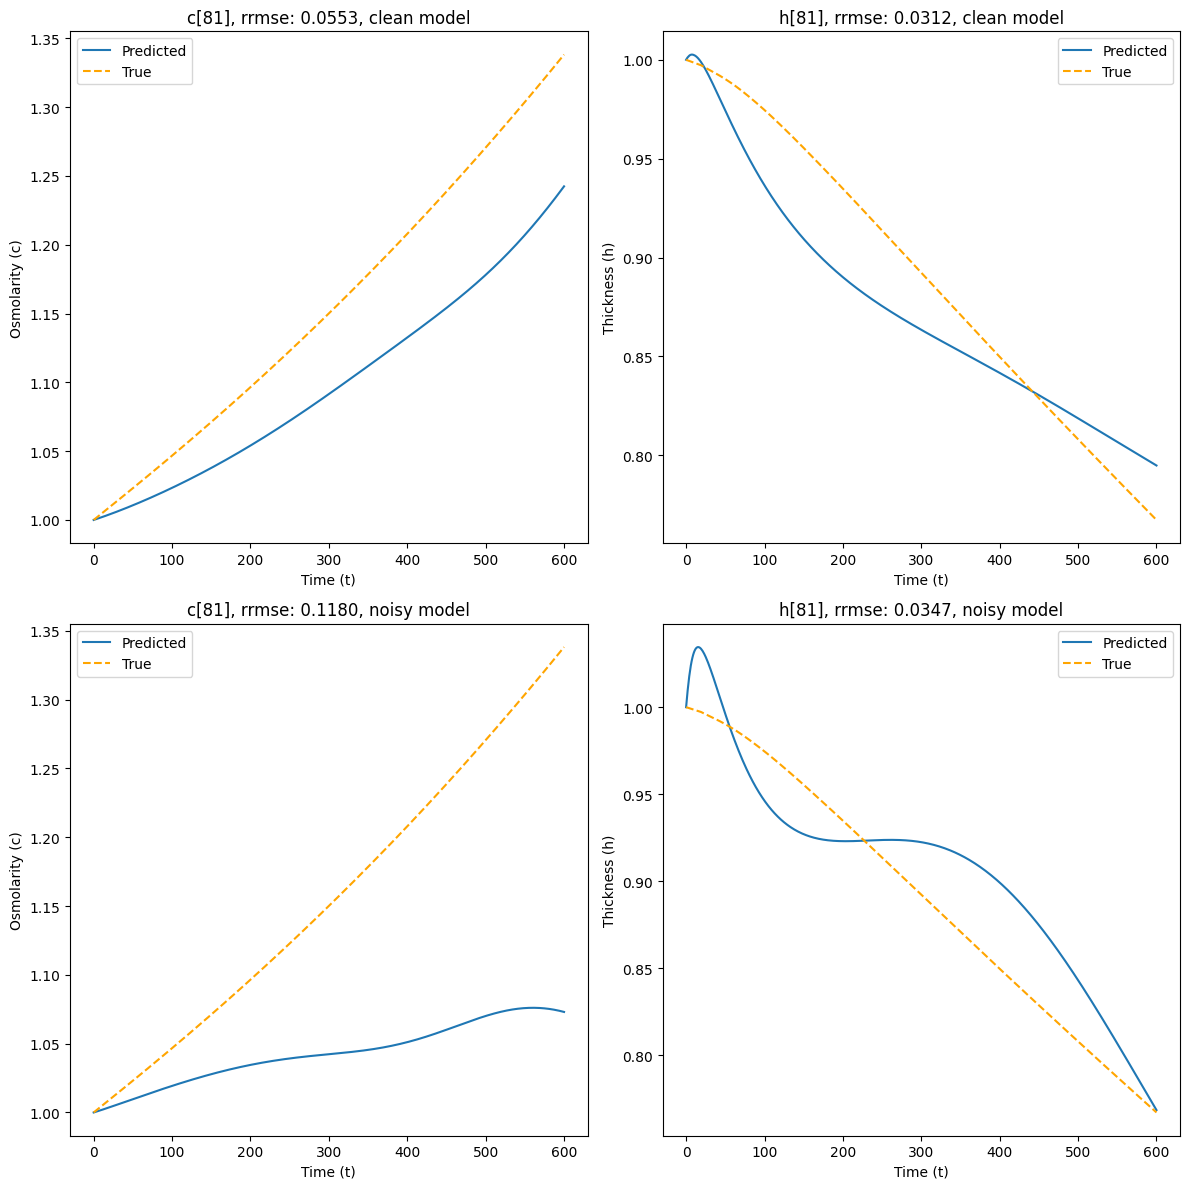

True PCA c: [-4.037518   -0.13876156  0.11194575 -0.03796371]
Predicted PCA c (clean): [[-5.5841208   0.10451533 -0.02111376  0.03899309]]
Predicted PCA c (noisy): [[-7.3910522  -0.04771441 -0.01024514 -0.08494268]]
True PCA h: [-1.1312371  -0.28236336  0.21582377  0.03167515]
Predicted PCA h (clean): [[ 5.9348507e+00  2.3375215e-01 -4.0304288e-03  8.0734961e-02]]
Predicted PCA h (noisy): [[ 6.69449     0.48165894 -0.27737477  0.53138924]]


In [140]:
n = np.random.choice(len(X_test_calculated_pca_clean))  # Randomly select an index for testing
true_pca_c = y_test_c_calculated_pca[n]
pred_pca_c_clean = model_c_clean.predict(X_test_calculated_pca_clean[n].reshape(1, -1))
pred_c_clean = pca_c.inverse_transform(pred_pca_c_clean)

pred_pca_c_noisy = model_c_noisy.predict(X_test_calculated_pca_noisy[n].reshape(1, -1))
pred_c_noisy = pca_c.inverse_transform(pred_pca_c_noisy)

true_pca_h = data_h_test_pca[n]
pred_pca_h_clean = model_h_clean.predict(X_test_calculated_pca_clean[n].reshape(1, -1))
pred_h_clean = pca_h.inverse_transform(pred_pca_h_clean)

pred_pca_h_noisy = model_h_noisy.predict(X_test_calculated_pca_noisy[n].reshape(1, -1))
pred_h_noisy = pca_h.inverse_transform(pred_pca_h_noisy)

fig, axs = plt.subplots(2, 2, figsize=(12, 12))  # 3 row, 2 columns

# Plot data_c[n]
axs[0,0].plot(pred_c_clean.T)
axs[0,0].plot(y_test_c_calculated[n], linestyle='--', color='orange')  # True data for comparison
axs[0,0].set_title(f'c[{n}], rrmse: {rrmse_c_calculated_clean[n]:.4f}, clean model')
axs[0,0].set_xlabel('Time (t)')
axs[0,0].set_ylabel('Osmolarity (c)')
axs[0,0].legend(['Predicted', 'True'])

# Plot data_h[n]
axs[0,1].plot(pred_h_clean.T)
axs[0,1].plot(y_test_h_calculated[n], linestyle='--', color='orange')  # True data for comparison
axs[0,1].set_title(f'h[{n}], rrmse: {rrmse_h_calculated_clean[n]:.4f}, clean model')
axs[0,1].set_xlabel('Time (t)')
axs[0,1].set_ylabel('Thickness (h)')
axs[0,1].legend(['Predicted', 'True'])


# Plot data_c[n]

axs[1,0].plot(pred_c_noisy.T)
axs[1,0].plot(y_test_c_calculated[n], linestyle='--', color='orange')  # True data for comparison
axs[1,0].set_title(f'c[{n}], rrmse: {rrmse_c_calculated_noisy[n]:.4f}, noisy model')
axs[1,0].set_xlabel('Time (t)')
axs[1,0].set_ylabel('Osmolarity (c)')
axs[1,0].legend(['Predicted', 'True'])

# Plot data_h[n]
axs[1,1].plot(pred_h_noisy.T)
axs[1,1].plot(y_test_h_calculated[n], linestyle='--', color='orange')  # True data for comparison
axs[1,1].set_title(f'h[{n}], rrmse: {rrmse_h_calculated_noisy[n]:.4f}, noisy model')
axs[1,1].set_xlabel('Time (t)')
axs[1,1].set_ylabel('Thickness (h)')
axs[1,1].legend(['Predicted', 'True'])

plt.tight_layout()
plt.show()

print(f"True PCA c: {true_pca_c}")
print(f"Predicted PCA c (clean): {pred_pca_c_clean}")
print(f"Predicted PCA c (noisy): {pred_pca_c_noisy}")
print(f"True PCA h: {true_pca_h}")
print(f"Predicted PCA h (clean): {pred_pca_h_clean}")
print(f"Predicted PCA h (noisy): {pred_pca_h_noisy}")

In [141]:
# Calculate predictions for f from predictions_c_calculated and f_0
# f_0 is the fifth entry of data_p_experimental_nondimensional (index 4)
f_0_experimental = data_p_experimental_nondimensional[:, 4]  # shape: (num_samples,)

# predictions_c_calculated shape: (num_samples, 601)
# We want to multiply each row of predictions_c_calculated by the corresponding f_0
predictions_f_calculated_clean = predictions_c_calculated_clean * f_0_experimental[:, np.newaxis]

predictions_f_calculated_noisy = predictions_c_calculated_noisy * f_0_experimental[:, np.newaxis]


In [142]:
def calculate_I(h, f, phi, I_0=1.0):
    return I_0 * (1 - np.exp(-phi * h * f)) / (1 + f ** 2)

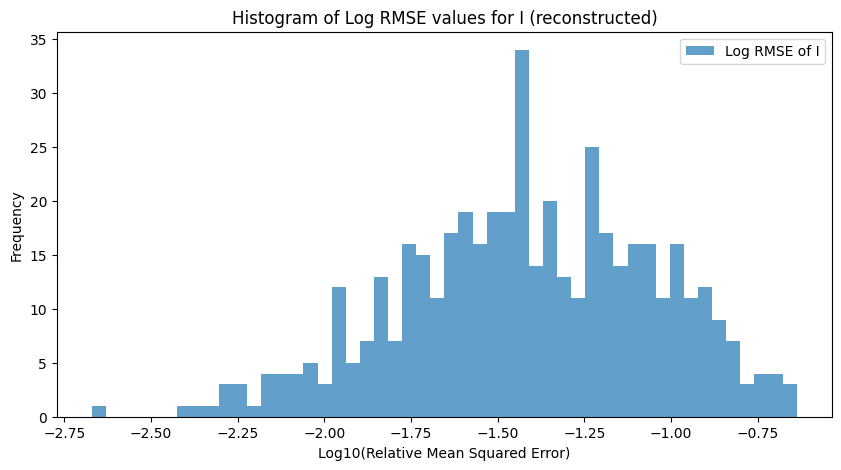

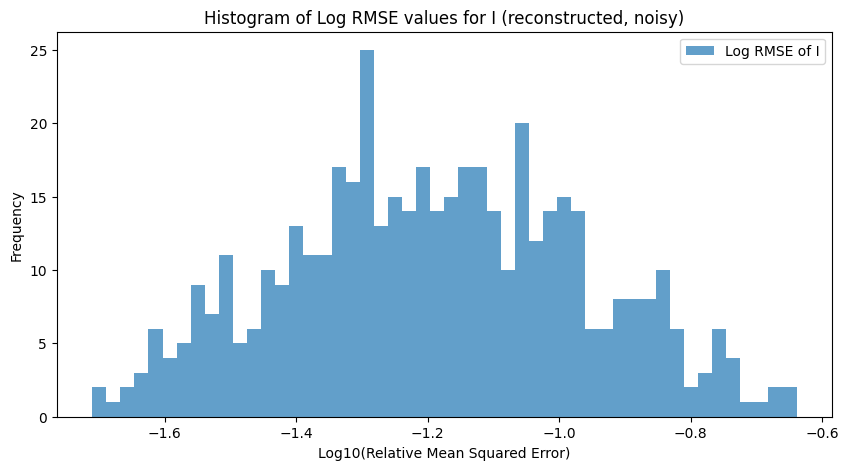

In [143]:
# Ensure phi is broadcastable to shape (num_samples, 601)
phi_expanded = data_p_experimental_nondimensional[:, 6][:, np.newaxis]  # shape: (num_samples, 1)

# Calculate I_pred using predictions_h_calculated and predictions_f_calculated
I_0_pred_clean = 1/calculate_I(predictions_h_calculated_clean[:,0].reshape(phi_expanded.shape), predictions_f_calculated_clean[:,0].reshape(phi_expanded.shape), phi=phi_expanded)
I_pred_clean = calculate_I(predictions_h_calculated_clean, predictions_f_calculated_clean, phi=phi_expanded, I_0=I_0_pred_clean)

I_0_pred_noisy = 1/calculate_I(predictions_h_calculated_noisy[:,0].reshape(phi_expanded.shape), predictions_f_calculated_noisy[:,0].reshape(phi_expanded.shape), phi=phi_expanded)
I_pred_noisy = calculate_I(predictions_h_calculated_noisy, predictions_f_calculated_noisy, phi=phi_expanded, I_0=I_0_pred_noisy)

# Compute relative MSE for each sample
rel_rmse_I_clean = np.sqrt(np.sum((I_pred_clean - data_I_calculated) ** 2, axis=1) / np.sum(data_I_calculated ** 2, axis=1))
rel_rmse_I_noisy = np.sqrt(np.sum((I_pred_noisy - data_I_calculated) ** 2, axis=1) / np.sum(data_I_calculated ** 2, axis=1))

# Plot histogram of log10(relative MSE)
plt.figure(figsize=(10, 5))
plt.hist(np.log10(rel_rmse_I_clean), bins=50, alpha=0.7, label='Log RMSE of I')
plt.xlabel('Log10(Relative Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values for I (reconstructed)')
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(np.log10(rel_rmse_I_noisy), bins=50, alpha=0.7, label='Log RMSE of I')
plt.xlabel('Log10(Relative Mean Squared Error)')
plt.ylabel('Frequency')
plt.title('Histogram of Log RMSE values for I (reconstructed, noisy)')
plt.legend()
plt.show()

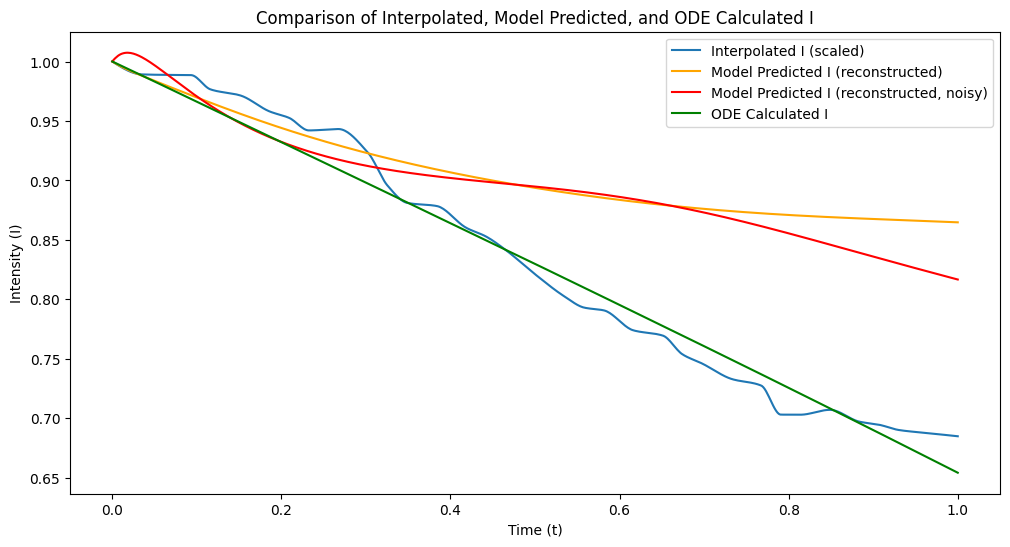

In [144]:
n = np.random.randint(0, len(I_scaled_interp))

plt.figure(figsize=(12, 6))
plt.plot(t_scaled_interp[n], I_scaled_interp[n], label='Interpolated I (scaled)')
plt.plot(t_scaled_interp[n], I_pred_clean[n], color='orange', label='Model Predicted I (reconstructed)')
plt.plot(t_scaled_interp[n], I_pred_noisy[n], color='red', label='Model Predicted I (reconstructed, noisy)')
plt.plot(t_scaled_interp[n], data_I_calculated[n], color='green', label='ODE Calculated I')
plt.xlabel('Time (t)')
plt.ylabel('Intensity (I)')
plt.title('Comparison of Interpolated, Model Predicted, and ODE Calculated I')
plt.legend()
plt.show()

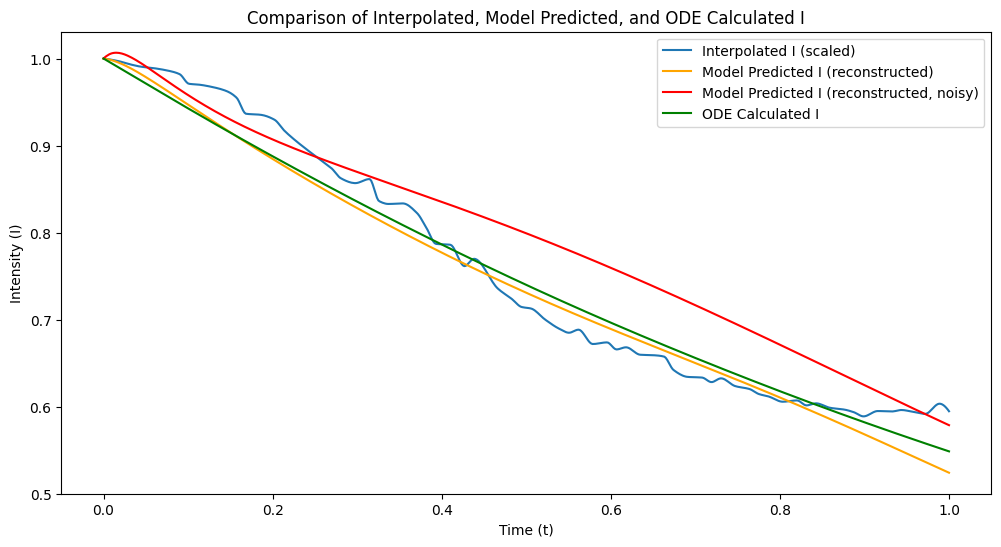

In [145]:
n = np.random.randint(0, len(I_scaled_interp))

plt.figure(figsize=(12, 6))
plt.plot(t_scaled_interp[n], I_scaled_interp[n], label='Interpolated I (scaled)')
plt.plot(t_scaled_interp[n], I_pred_clean[n], color='orange', label='Model Predicted I (reconstructed)')
plt.plot(t_scaled_interp[n], I_pred_noisy[n], color='red', label='Model Predicted I (reconstructed, noisy)')
plt.plot(t_scaled_interp[n], data_I_calculated[n], color='green', label='ODE Calculated I')
plt.xlabel('Time (t)')
plt.ylabel('Intensity (I)')
plt.title('Comparison of Interpolated, Model Predicted, and ODE Calculated I')
plt.legend()
plt.show()

In [146]:
# import os

# # Path where plots will be stored
# plot_dir_h = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/FNN_PCA_plots/h_plots"
# plot_dir_c = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/FNN_PCA_plots/c_plots"
# plot_dir_f = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/FNN_PCA_plots/f_plots"
# plot_dir_I = "C:/Users/arnab/OneDrive/Desktop/Study material/summer 24/Research/New equations/Plots/FNN_PCA_plots/I_plots"
# os.makedirs(plot_dir_h, exist_ok=True)  # Create the folder if it doesn't exist
# os.makedirs(plot_dir_c, exist_ok=True)  # Create the folder if it doesn't exist
# os.makedirs(plot_dir_I, exist_ok=True)  # Create the folder if it doesn't exist
# os.makedirs(plot_dir_f, exist_ok=True)  # Create the folder if it doesn't exist

# # Loop through all 467 samples
# for idx in range(467):
#     # Get data for this sample (already loaded in your variables)
#     id = id_array[idx]
#     t = t_scaled_interp[idx]
#     I_exp = I_scaled_interp[idx]
#     h_true = data_h_calculated[idx]
#     c_true = data_c_caluculated[idx]
#     f_true = data_f_calculated[idx]
    
#     I_pred_n = I_pred[idx]
#     h_pred = predictions_h_calculated[idx]
#     c_pred = predictions_c_calculated[idx]
#     f_pred = predictions_f_calculated[idx]
    
#     I_ode = data_I_calculated[idx]
    
#     fig1, ax1 = plt.subplots()
#     ax1.plot(t, I_exp, label='Experimental I (scaled)')
#     ax1.plot(t, I_pred_n, label='Model Predicted I (reconstructed)')
#     ax1.plot(t, I_ode, color='green', label='ODE Calculated I')
#     ax1.set_title(f'I for Sample {id}')
#     ax1.set_xlabel('Time Index')
#     ax1.set_ylabel('I')
#     ax1.legend()
#     fig1.tight_layout()
#     fig1.savefig(f"{plot_dir_I}/I_{id}.png")
#     plt.close(fig1)

#     fig2, ax2 = plt.subplots()
#     ax2.plot(t, h_true, label='ODE calculated h')
#     ax2.plot(t, h_pred, label='Model Predicted h')
#     ax2.set_title(f'h for Sample {id}')
#     ax2.set_xlabel('Time Index')
#     ax2.set_ylabel('h')
#     ax2.legend()
#     fig2.tight_layout()
#     fig2.savefig(f"{plot_dir_h}/h_{id}.png")
#     plt.close(fig2)
    
#     fig3, ax3 = plt.subplots()
#     ax3.plot(t, c_true, label='ODE calculated c')
#     ax3.plot(t, c_pred, label='Model Predicted c')
#     ax3.set_title(f'c for Sample {id}')
#     ax3.set_xlabel('Time Index')
#     ax3.set_ylabel('c')
#     ax3.legend()
#     fig3.tight_layout()
#     fig3.savefig(f"{plot_dir_c}/c_{id}.png")
#     plt.close(fig3)
    
#     fig4, ax4 = plt.subplots()
#     ax4.plot(t, f_true, label='ODE calculated f')
#     ax4.plot(t, f_pred, label='Model Predicted f')
#     ax4.set_title(f'f for Sample {id}')
#     ax4.set_xlabel('Time Index')
#     ax4.set_ylabel('f')
#     ax4.legend()
#     fig4.tight_layout()
#     fig4.savefig(f"{plot_dir_f}/f_{id}.png")
#     plt.close(fig4)


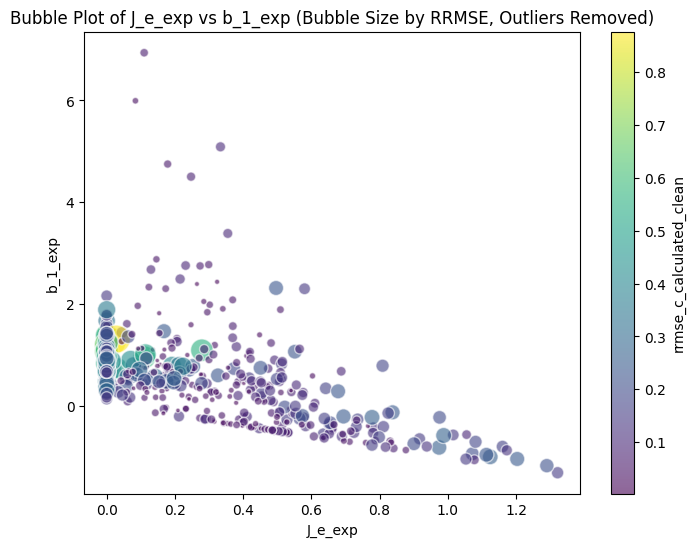

In [147]:
# Remove outliers from b_1_exp
filtered_indices_b1 = b_1_exp < np.max(b_1_exp)
# Apply the same filtering to J_e_exp and other arrays
b_1_exp_filtered = b_1_exp[filtered_indices_b1]
J_e_exp_filtered = J_e_exp[filtered_indices_b1]
# Define sizes if not already defined
sizes = (rrmse_c_calculated_clean - np.min(rrmse_c_calculated_clean)) / (
    np.max(rrmse_c_calculated_clean) - np.min(rrmse_c_calculated_clean))

sizes = sizes * 400 + 10

sizes_filtered = sizes[filtered_indices_b1]
rrmse_c_calculated_clean_filtered = rrmse_c_calculated_clean[filtered_indices_b1]

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    J_e_exp_filtered,
    b_1_exp_filtered,
    s=sizes_filtered,
    c=rrmse_c_calculated_clean_filtered,
    cmap='viridis',
    alpha=0.6,
    edgecolors='w'
)

plt.colorbar(scatter, label='rrmse_c_calculated_clean')
plt.xlabel('J_e_exp')
plt.ylabel('b_1_exp')
plt.title('Bubble Plot of J_e_exp vs b_1_exp (Bubble Size by RRMSE, Outliers Removed)')
plt.show()


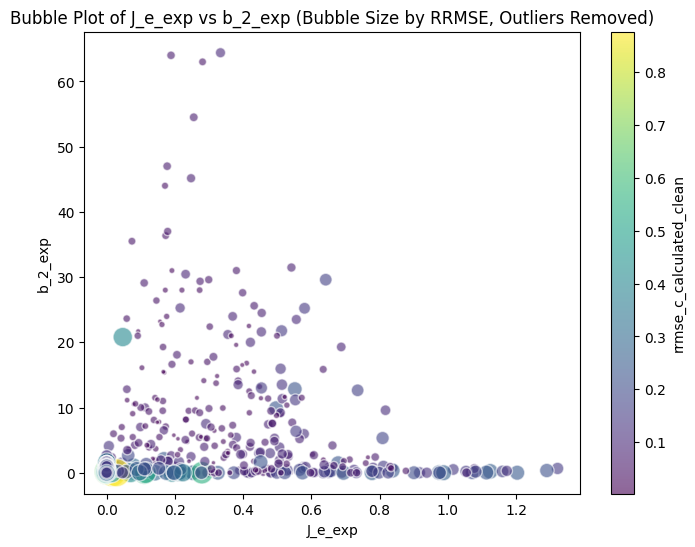

In [148]:
# Remove outliers from b_1_exp
filtered_indices_b2 = b_2_exp < np.max(b_2_exp)
# filtered_indices_b2 = b_2_exp < 10

# Apply the same filtering to J_e_exp and other arrays
b_2_exp_filtered = b_2_exp[filtered_indices_b2]
J_e_exp_filtered = J_e_exp[filtered_indices_b2]
sizes_filtered = sizes[filtered_indices_b2]
rrmse_c_calculated_clean_filtered = rrmse_c_calculated_clean[filtered_indices_b2]

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    J_e_exp_filtered,
    b_2_exp_filtered,
    s=sizes_filtered,
    c=rrmse_c_calculated_clean_filtered,
    cmap='viridis',
    alpha=0.6,
    edgecolors='w'
)

plt.colorbar(scatter, label='rrmse_c_calculated_clean')
plt.xlabel('J_e_exp')
plt.ylabel('b_2_exp')
plt.title('Bubble Plot of J_e_exp vs b_2_exp (Bubble Size by RRMSE, Outliers Removed)')
plt.show()


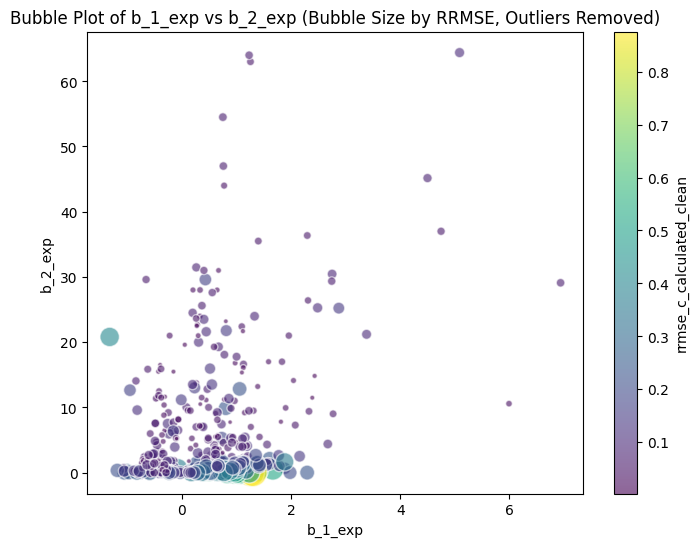

In [149]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    b_1_exp_filtered,
    b_2_exp_filtered,
    s=sizes_filtered,
    c=rrmse_c_calculated_clean_filtered,
    cmap='viridis',
    alpha=0.6,
    edgecolors='w'
)

plt.colorbar(scatter, label='rrmse_c_calculated_clean')
plt.xlabel('b_1_exp')
plt.ylabel('b_2_exp')
plt.title('Bubble Plot of b_1_exp vs b_2_exp (Bubble Size by RRMSE, Outliers Removed)')
plt.show()

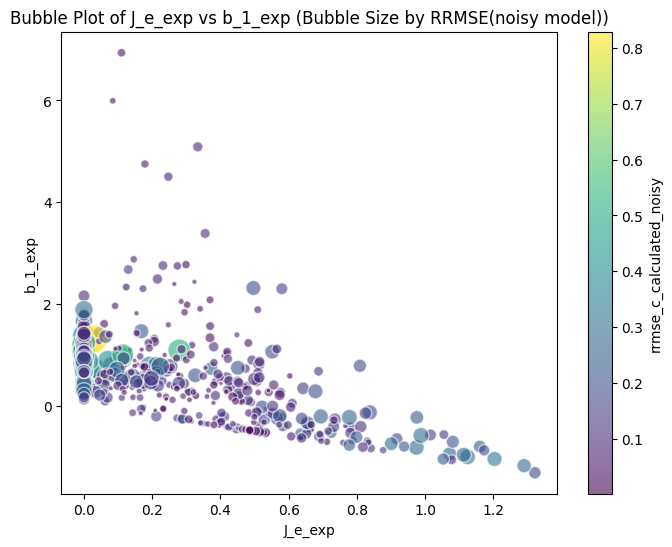

In [150]:
# Remove outliers from b_1_exp
filtered_indices_b1 = b_1_exp < np.max(b_1_exp)
# Apply the same filtering to J_e_exp and other arrays
b_1_exp_filtered = b_1_exp[filtered_indices_b1]
J_e_exp_filtered = J_e_exp[filtered_indices_b1]
# Define sizes if not already defined
sizes = (rrmse_c_calculated_clean - np.min(rrmse_c_calculated_clean)) / (
    np.max(rrmse_c_calculated_clean) - np.min(rrmse_c_calculated_clean))

sizes = sizes * 400 + 10

sizes_filtered = sizes[filtered_indices_b1]
rrmse_c_calculated_noisy_filtered = rrmse_c_calculated_noisy[filtered_indices_b1]

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    J_e_exp_filtered,
    b_1_exp_filtered,
    s=sizes_filtered,
    c=rrmse_c_calculated_noisy_filtered,
    cmap='viridis',
    alpha=0.6,
    edgecolors='w'
)

plt.colorbar(scatter, label='rrmse_c_calculated_noisy')
plt.xlabel('J_e_exp')
plt.ylabel('b_1_exp')
plt.title('Bubble Plot of J_e_exp vs b_1_exp (Bubble Size by RRMSE(noisy model))')
plt.show()


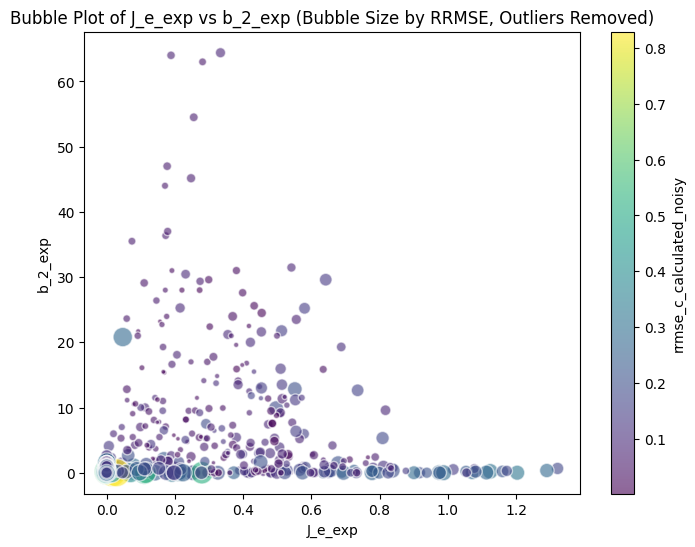

In [151]:
# Remove outliers from b_1_exp
filtered_indices_b2 = b_2_exp < np.max(b_2_exp)

# Apply the same filtering to J_e_exp and other arrays
b_2_exp_filtered = b_2_exp[filtered_indices_b2]
J_e_exp_filtered = J_e_exp[filtered_indices_b2]
sizes_filtered = sizes[filtered_indices_b2]
rrmse_c_calculated_noisy_filtered = rrmse_c_calculated_noisy[filtered_indices_b2]

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    J_e_exp_filtered,
    b_2_exp_filtered,
    s=sizes_filtered,
    c=rrmse_c_calculated_noisy_filtered,
    cmap='viridis',
    alpha=0.6,
    edgecolors='w'
)

plt.colorbar(scatter, label='rrmse_c_calculated_noisy')
plt.xlabel('J_e_exp')
plt.ylabel('b_2_exp')
plt.title('Bubble Plot of J_e_exp vs b_2_exp (Bubble Size by RRMSE, Outliers Removed)')
plt.show()


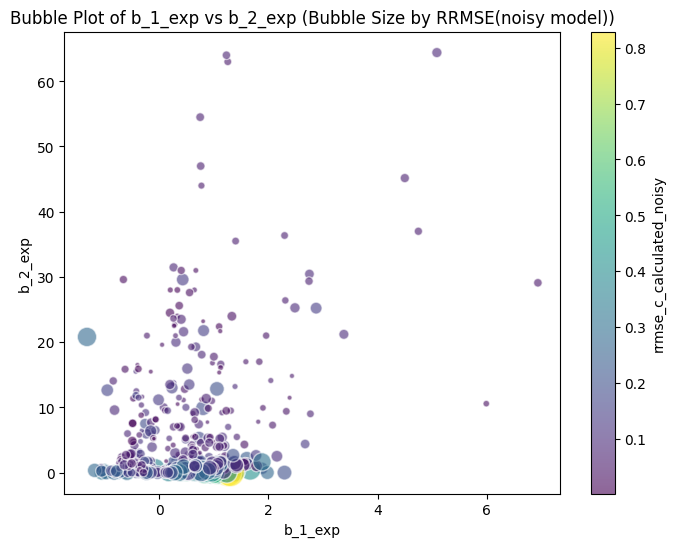

In [ ]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    b_1_exp_filtered,
    b_2_exp_filtered,
    s=sizes_filtered,
    c=rrmse_c_calculated_noisy_filtered,
    cmap='viridis',
    alpha=0.6,
    edgecolors='w'
)

plt.colorbar(scatter, label='rrmse_c_calculated_noisy')
plt.xlabel('b_1_exp')
plt.ylabel('b_2_exp')
plt.title('Bubble Plot of b_1_exp vs b_2_exp (Bubble Size by RRMSE(noisy model))')
plt.show()